<div align="center">

# Analisi sperimentale della sicurezza delle password

### Scenario di attacco offline · Raw-MD5 e bcrypt

`John the Ripper Jumbo` · `Python 3.10` · `Baseline CPU` · `Appendice GPU RTX 5070 Ti Laptop`

---

**Notebook completo**

</div>


# Dashboard di controllo

Questa è l’unica sezione dalla quale si decide quali prove facoltative eseguire. La baseline CPU con Raw-MD5 e bcrypt rimane sempre attiva perché costituisce il confronto richiesto dalla traccia.

Per cambiare configurazione basta modificare i cinque valori `True` e `False` nella cella seguente, salvare il notebook e usare **Restart Kernel and Run All**.

- `True` esegue la prova
- `False` salta la prova e mostra un breve messaggio

Le celle successive leggono questi valori ma non li ridefiniscono.


In [ ]:
# Importa gli strumenti necessari per mostrare il pannello.
from IPython.display import display, HTML


# ============================================================================
# MODIFICARE SOLTANTO I CINQUE VALORI TRUE E FALSE DI QUESTO BLOCCO
# ============================================================================

# Attiva oppure disattiva lo studio dei costi bcrypt 8, 10, 12 e 14.
RUN_BCRYPT_COST_STUDY = False

# Attiva oppure disattiva i benchmark CPU dedicati.
RUN_CPU_BENCHMARKS = False

# Attiva oppure disattiva la prova di scalabilità OpenMP.
RUN_CPU_SCALABILITY = False

# Attiva oppure disattiva i benchmark OpenCL della GPU.
RUN_GPU_BENCHMARKS = False

# Attiva oppure disattiva gli attacchi GPU con la wordlist controllata.
RUN_GPU_WORDLIST_ATTACKS = False

# ============================================================================
# FINE DELLE IMPOSTAZIONI MODIFICABILI
# ============================================================================


# Raccoglie i valori scelti senza modificarli.
CONTROL_FLAGS = {
    "RUN_BCRYPT_COST_STUDY": RUN_BCRYPT_COST_STUDY,
    "RUN_CPU_BENCHMARKS": RUN_CPU_BENCHMARKS,
    "RUN_CPU_SCALABILITY": RUN_CPU_SCALABILITY,
    "RUN_GPU_BENCHMARKS": RUN_GPU_BENCHMARKS,
    "RUN_GPU_WORDLIST_ATTACKS": RUN_GPU_WORDLIST_ATTACKS,
}

# Elenca i nomi riconosciuti dal notebook.
CONTROL_FLAG_NAMES = tuple(CONTROL_FLAGS)

# Individua valori scritti in modo diverso da True oppure False.
invalid_control_flags = [
    name
    for name, value in CONTROL_FLAGS.items()
    if not isinstance(value, bool)
]

# Blocca subito una configurazione non valida.
if invalid_control_flags:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise TypeError(
        "I flag devono contenere soltanto True o False: "
        + ", ".join(invalid_control_flags)
    )

# Definisce etichette, descrizioni e colori delle prove facoltative.
CONTROL_APPEARANCE = {
    "RUN_BCRYPT_COST_STUDY": (
        "Studio del costo bcrypt",
        "Misura i costi 8, 10, 12 e 14",
        "#9B51E0",
    ),
    "RUN_CPU_BENCHMARKS": (
        "Benchmark CPU dedicati",
        "Misura i backend CPU con il comando --test",
        "#2F80ED",
    ),
    "RUN_CPU_SCALABILITY": (
        "Scalabilità CPU OpenMP",
        "Confronta più configurazioni di thread",
        "#F2994A",
    ),
    "RUN_GPU_BENCHMARKS": (
        "Benchmark GPU OpenCL",
        "Misura i backend della RTX 5070 Ti Laptop",
        "#27AE60",
    ),
    "RUN_GPU_WORDLIST_ATTACKS": (
        "Attacchi GPU con wordlist",
        "Replica le due prove reali mediante OpenCL",
        "#00A3A3",
    ),
}

# Prepara le schede visuali dei cinque flag.
control_cards = []

# Costruisce una scheda per ogni prova facoltativa.
for key, (label, detail, color) in CONTROL_APPEARANCE.items():
    # Calcola e memorizza `active`.
    active = CONTROL_FLAGS[key]
    # Calcola e memorizza `state`.
    state = "ATTIVO" if active else "DISATTIVATO"
    # Calcola e memorizza `background`.
    background = "#ECFDF3" if active else "#F7F9FC"
    # Calcola e memorizza `state_color`.
    state_color = "#18794E" if active else "#697586"
    # Calcola e memorizza `symbol`.
    symbol = "✓" if active else "—"
    # Aggiunge il risultato alla raccolta corrente.
    control_cards.append(
        f"""
        <div style="background:{background};border:1px solid #E2E8F0;
                    border-top:4px solid {color};padding:13px 14px;
                    border-radius:12px;min-height:105px;">
          <div style="font-size:11px;font-weight:800;color:{state_color};
                      letter-spacing:.8px;">{symbol}&nbsp; {state}</div>
          <div style="font-size:14px;font-weight:800;color:#172033;
                      margin-top:7px;">{label}</div>
          <div style="font-size:12px;color:#52606D;line-height:1.45;
                      margin-top:5px;">{detail}</div>
        </div>
        """
    )

# Conta quante prove facoltative sono attive.
active_control_count = sum(CONTROL_FLAGS.values())

# Prepara un avviso soltanto per un benchmark GPU privo del riferimento CPU.
dependency_note = ""

# Spiega che il rapporto GPU/CPU richiede entrambi i benchmark.
if RUN_GPU_BENCHMARKS and not RUN_CPU_BENCHMARKS:
    # Calcola e memorizza `dependency_note`.
    dependency_note = """
    <div style="background:#FFF8E6;border-left:5px solid #F2994A;
                padding:11px 14px;border-radius:9px;margin-top:12px;
                color:#6B4F10;font-size:12px;line-height:1.5;">
      Il benchmark GPU verrà eseguito, ma il rapporto GPU/CPU richiede
      anche RUN_CPU_BENCHMARKS = True.
    </div>
    """

# Costruisce il pannello finale senza dipendere da widget esterni.
control_dashboard = f"""
<div style="border:1px solid #D9E2EC;border-radius:18px;background:#FFFFFF;
            box-shadow:0 12px 30px rgba(23,32,51,.09);overflow:hidden;
            margin:6px 0 22px 0;">
  <div style="background:linear-gradient(120deg,#172033 0%,#244A78 58%,#1D6F5F 100%);
              color:white;padding:22px 24px;">
    <div style="font-size:11px;letter-spacing:1.5px;font-weight:800;
                opacity:.78;">CENTRO DI CONTROLLO</div>
    <div style="display:flex;justify-content:space-between;align-items:end;
                gap:18px;flex-wrap:wrap;margin-top:5px;">
      <div>
        <div style="font-size:25px;font-weight:850;">Sessione sperimentale</div>
        <div style="font-size:13px;line-height:1.5;opacity:.88;margin-top:5px;">
          Tutte le prove facoltative dipendono solo dai cinque flag qui sopra.
        </div>
      </div>
      <div style="background:rgba(255,255,255,.14);padding:9px 14px;
                  border-radius:999px;font-size:12px;font-weight:800;">
        {active_control_count} di 5 opzionali attive
      </div>
    </div>
  </div>
  <div style="padding:16px 18px 18px 18px;">
    <div style="display:flex;justify-content:space-between;align-items:center;
                gap:12px;background:#EEF4FF;border-left:5px solid #2F80ED;
                padding:12px 15px;border-radius:10px;margin-bottom:13px;">
      <div>
        <div style="font-size:14px;font-weight:800;color:#172033;">
          Baseline CPU Raw-MD5 e bcrypt
        </div>
        <div style="font-size:12px;color:#52606D;margin-top:3px;">
          Parte centrale richiesta dalla traccia
        </div>
      </div>
      <div style="background:#2F80ED;color:white;padding:7px 12px;
                  border-radius:999px;font-size:10px;font-weight:800;">
        SEMPRE ATTIVA
      </div>
    </div>
    <div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(185px,1fr));
                gap:10px;">
      {''.join(control_cards)}
    </div>
    {dependency_note}
    <div style="font-size:12px;color:#52606D;line-height:1.55;margin-top:13px;">
      Modificare i valori True e False, salvare il notebook e usare
      Restart Kernel and Run All. Nessuna cella successiva ridefinisce i flag.
    </div>
  </div>
</div>
"""

# Visualizza la dashboard nel notebook.
display(HTML(control_dashboard))


## Risultati in sintesi

Il laboratorio confronta due hash della stessa password mediante la stessa wordlist di 20.000 candidate sul medesimo sistema. La candidata corretta occupa l’ultima posizione e obbliga John the Ripper a esaminare l’intero insieme.

<div style="display:grid;grid-template-columns:repeat(4,minmax(150px,1fr));gap:12px;margin:8px 0 18px 0;">
  <div style="background:#F4F8FF;border-left:5px solid #2F80ED;padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:#52606D;text-transform:uppercase;">Candidate</div>
    <div style="font-size:26px;font-weight:700;color:#172033;">20.000</div>
  </div>
  <div style="background:#F4F8FF;border-left:5px solid #2F80ED;padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:#52606D;text-transform:uppercase;">Raw-MD5 su CPU</div>
    <div style="font-size:22px;font-weight:700;color:#172033;">Da misurare</div>
  </div>
  <div style="background:#FFF5F5;border-left:5px solid #EB5757;padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:#52606D;text-transform:uppercase;">bcrypt costo 12 su CPU</div>
    <div style="font-size:22px;font-weight:700;color:#172033;">Da misurare</div>
  </div>
  <div style="background:#F0FFF4;border-left:5px solid #27AE60;padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:#52606D;text-transform:uppercase;">RTX 5070 Ti Laptop</div>
    <div style="font-size:22px;font-weight:700;color:#172033;">Appendice controllata</div>
  </div>
</div>

I riquadri non anticipano alcun risultato. La dashboard quantitativa viene costruita dalle celle di analisi usando soltanto le misure prodotte nella sessione corrente. Una sessione interrotta non genera conclusioni sperimentali valide.


# 1. Contesto, modello di minaccia e domande di ricerca

In un attacco online l’aggressore deve interagire con un servizio e può essere ostacolato da blocchi dell’account, ritardi, CAPTCHA e limiti al numero di tentativi. Nel modello offline l’attaccante possiede una copia dell’hash e può verificare localmente le password candidate senza dipendere dal sistema originale.

La pipeline concettuale segue questo ordine

<div align="center">

`wordlist` ➜ `password candidata` ➜ `funzione di verifica` ➜ `confronto con l’hash` ➜ `corrispondenza oppure mancata corrispondenza`

</div>

La sostenibilità dell’attacco dipende dalla qualità della password e dal costo della funzione impiegata per verificarla. Il laboratorio mantiene invariata la password per isolare sperimentalmente il secondo fattore.


## Domande di ricerca

Il lavoro è guidato da tre domande.

1. Quanto cambia la velocità di verifica quando la stessa password è memorizzata con Raw-MD5 oppure con bcrypt?
2. Quale ruolo svolgono il salt e il parametro di costo nel modello di attacco offline?
3. In che misura il calcolo parallelo aumenta il throughput e perché tale vantaggio non elimina la protezione introdotta da una funzione deliberatamente lenta?

L’ipotesi è che Raw-MD5 costituisca una baseline estremamente favorevole all’attaccante, mentre bcrypt riduca drasticamente il numero di candidate verificabili nell’unità di tempo.

## Disegno sperimentale

La macchina, la versione di John the Ripper, la password, la wordlist e la posizione della candidata corretta rimangono invariati. Nella baseline CPU cambia soltanto il formato dell’hash. L’appendice GPU costituisce un’analisi separata e non modifica il confronto ufficiale.

| Variabile | Valore controllato |
|---|---|
| Password | Identica nei due casi |
| Wordlist | 20.000 candidate uniche |
| Posizione della password corretta | Ultima riga |
| Strumento | John the Ripper Jumbo |
| Piattaforma principale | CPU rilevata nella sessione |
| Strategia | Modalità wordlist |
| Variabile indipendente | Raw-MD5 oppure bcrypt con costo 12 |
| Metriche | Candidate al secondo, tempo totale ed esito |
| Appendice | NVIDIA GeForce RTX 5070 Ti Laptop GPU |


# 2. Configurazione dell’ambiente

La prima cella tecnica individua la cartella principale del progetto, crea le sottocartelle necessarie e descrive il computer usato per la prova. Non contiene copie dei flag e non può quindi cambiare le scelte fatte nella dashboard.

Il percorso di John the Ripper viene ricavato automaticamente. In questo modo il progetto può essere spostato su un altro computer senza riscrivere tutti i percorsi.

Il codice è commentato istruzione per istruzione, così è possibile seguire anche i passaggi più tecnici senza doverli dedurre.


In [33]:
# Importa Path per gestire i percorsi in modo portabile.
from pathlib import Path

# Importa i moduli standard necessari al protocollo.
import hashlib
# Importa json.
import json
# Importa os.
import os
# Importa platform.
import platform
# Importa random.
import random
# Importa re.
import re
# Importa shutil.
import shutil
# Importa subprocess.
import subprocess
# Importa time.
import time
# Importa datetime dal modulo datetime.
from datetime import datetime

# Importa le librerie scientifiche e di sistema.
import bcrypt
# Importa pandas.
import pandas as pd
# Importa matplotlib.pyplot.
import matplotlib.pyplot as plt
# Importa psutil.
import psutil

# Importa gli strumenti di visualizzazione di Jupyter.
from IPython.display import display, HTML


# Cerca la radice del progetto risalendo le cartelle.
def locate_project_root() -> Path:
    # Calcola e memorizza `start`.
    start = Path.cwd().resolve()
    # Ripete il blocco per ogni elemento della raccolta.
    for candidate in [start, *start.parents]:
        # Verifica la condizione prima di eseguire il blocco seguente.
        if (candidate / "JtR" / "run" / "john.exe").exists():
            # Restituisce il risultato al chiamante.
            return candidate
    # Verifica la condizione prima di eseguire il blocco seguente.
    if start.name.lower() in {"notebook", "notebooks"}:
        # Restituisce il risultato al chiamante.
        return start.parent
    # Restituisce il risultato al chiamante.
    return start


# Individua la radice e l'eseguibile di John.
PROJECT_ROOT = locate_project_root()
# Costruisce il percorso dell'eseguibile di John the Ripper.
JOHN_EXE = PROJECT_ROOT / "JtR" / "run" / "john.exe"

# Definisce e crea le cartelle operative.
DIRECTORIES = {
    "hashes": PROJECT_ROOT / "hashes",
    "wordlists": PROJECT_ROOT / "wordlists",
    "outputs": PROJECT_ROOT / "outputs",
    "figures": PROJECT_ROOT / "figures",
    "report": PROJECT_ROOT / "report",
}
# Ripete il blocco per ogni elemento della raccolta.
for directory in DIRECTORIES.values():
    # Crea la cartella quando non esiste ancora.
    directory.mkdir(parents=True, exist_ok=True)

# Definisce una palette coerente per figure e pannelli.
COLORS = {
    "md5": "#2F80ED",
    "bcrypt": "#EB5757",
    "gpu": "#27AE60",
    "accent": "#F2C94C",
    "dark": "#172033",
    "muted": "#52606D",
    "background": "#F7F9FC",
}

# Verifica che la dashboard sia stata eseguita prima di questa cella.
if "CONTROL_FLAGS" not in globals():
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError(
        "Eseguire prima la dashboard di controllo all'inizio del notebook."
    )

# Ricontrolla che tutti i valori siano booleani senza ridefinirli.
if any(not isinstance(value, bool) for value in CONTROL_FLAGS.values()):
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise TypeError("Tutti i flag della dashboard devono essere True oppure False.")

# Definisce durate e soglie prudenziali.
BENCHMARK_SECONDS = 10
# Fissa il timeout massimo degli attacchi controllati.
COMMAND_TIMEOUT_SECONDS = 180
# Fissa la pausa tra due carichi intensivi sulla CPU.
CPU_COOLDOWN_SECONDS = 15
# Fissa la temperatura massima ammessa all'avvio della prova GPU.
GPU_START_TEMPERATURE_C = 70
# Fissa la temperatura richiesta dopo un carico GPU.
GPU_COOLDOWN_TEMPERATURE_C = 65
# Fissa il tempo massimo dedicato al raffreddamento della GPU.
GPU_MAX_WAIT_SECONDS = 180

# Identifica univocamente la sessione corrente.
SESSION_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
# Costruisce il percorso del checkpoint della sessione.
CHECKPOINT_FILE = DIRECTORIES["outputs"] / "checkpoint_sessione_corrente.json"

# Rileva il modello CPU senza fissarlo nel testo.
CPU_MODEL = (
    platform.processor().strip()
    or os.environ.get("PROCESSOR_IDENTIFIER", "").strip()
    or "non rilevato"
)

# Rileva lo stato di alimentazione quando disponibile.
BATTERY_STATUS = psutil.sensors_battery()
# Registra se il portatile è collegato alla rete elettrica.
POWER_PLUGGED = (
    None
    if BATTERY_STATUS is None
    else bool(BATTERY_STATUS.power_plugged)
)

# Visualizza il riepilogo della sessione.
print("=== CONFIGURAZIONE DEL LABORATORIO ===")
# Mostra il valore nel riepilogo della cella.
print(f"Sessione              {SESSION_ID}")
# Mostra il valore nel riepilogo della cella.
print(f"Python                 {platform.python_version()}")
# Mostra il valore nel riepilogo della cella.
print(f"Sistema                {platform.system()} {platform.release()}")
# Mostra il valore nel riepilogo della cella.
print(f"CPU                     {CPU_MODEL}")
# Mostra il valore nel riepilogo della cella.
print(f"CPU logiche             {psutil.cpu_count(logical=True)}")
# Mostra il valore nel riepilogo della cella.
print(f"CPU fisiche             {psutil.cpu_count(logical=False)}")
# Mostra il valore nel riepilogo della cella.
print(f"RAM totale              {psutil.virtual_memory().total / (1024**3):.2f} GB")
# Mostra il valore nel riepilogo della cella.
print(f"John presente           {'SÌ' if JOHN_EXE.exists() else 'NO'}")
# Mostra il valore nel riepilogo della cella.
print(
    "Alimentazione          "
    + (
        "rete elettrica"
        if POWER_PLUGGED is True
        else "batteria"
        if POWER_PLUGGED is False
        else "non rilevabile"
    )
)
# Mostra il valore nel riepilogo della cella.
print(f"Studio costo bcrypt     {RUN_BCRYPT_COST_STUDY}")
# Mostra il valore nel riepilogo della cella.
print(f"Benchmark CPU           {RUN_CPU_BENCHMARKS}")
# Mostra il valore nel riepilogo della cella.
print(f"Scalabilità CPU         {RUN_CPU_SCALABILITY}")
# Mostra il valore nel riepilogo della cella.
print(f"Benchmark GPU           {RUN_GPU_BENCHMARKS}")
# Mostra il valore nel riepilogo della cella.
print(f"Attacchi GPU opzionali  {RUN_GPU_WORDLIST_ATTACKS}")


=== CONFIGURAZIONE DEL LABORATORIO ===
Sessione              20260729_184436
Python                 3.10.11
Sistema                Windows 10
CPU                     Intel64 Family 6 Model 198 Stepping 2, GenuineIntel
CPU logiche             24
CPU fisiche             24
RAM totale              63.38 GB
John presente           SÌ
Alimentazione          rete elettrica
Studio costo bcrypt     False
Benchmark CPU           False
Scalabilità CPU         False
Benchmark GPU           False
Attacchi GPU opzionali  False


### Lettura del risultato

La cella documenta il sistema effettivamente utilizzato nella sessione corrente. Versione di Python, sistema operativo, modello della CPU, numero di unità di elaborazione e memoria vengono acquisiti automaticamente e non sono fissati nel testo.

La memoria disponibile non costituisce la variabile principale per Raw-MD5 o bcrypt. Viene comunque registrata per descrivere integralmente la piattaforma di prova.


## Funzioni di supporto

Le funzioni seguenti centralizzano l’esecuzione di John, la formattazione degli output e l’estrazione delle metriche. In questo modo le celle sperimentali restano brevi e leggibili, mentre la gestione degli errori rimane uniforme.

In [34]:
# Esegue un comando esterno con acquisizione uniforme e timeout.
def run_command(command, *, env=None, timeout=None):
    # Gestisce in modo controllato le possibili eccezioni.
    try:
        # Calcola e memorizza `completed`.
        completed = subprocess.run(
            [str(item) for item in command],
            cwd=JOHN_EXE.parent,
            capture_output=True,
            text=True,
            encoding="utf-8",
            errors="replace",
            env=env,
            timeout=timeout,
            check=False,
        )
        # Calcola e memorizza `output`.
        output = "\n".join(
            part.strip()
            for part in (completed.stdout, completed.stderr)
            if part.strip()
        )
        # Restituisce il risultato al chiamante.
        return completed.returncode, output
    # Gestisce l'eccezione prevista.
    except subprocess.TimeoutExpired as error:
        # Calcola e memorizza `stdout`.
        stdout = error.stdout or ""
        # Calcola e memorizza `stderr`.
        stderr = error.stderr or ""
        # Verifica la condizione prima di eseguire il blocco seguente.
        if isinstance(stdout, bytes):
            # Calcola e memorizza `stdout`.
            stdout = stdout.decode("utf-8", errors="replace")
        # Verifica la condizione prima di eseguire il blocco seguente.
        if isinstance(stderr, bytes):
            # Calcola e memorizza `stderr`.
            stderr = stderr.decode("utf-8", errors="replace")
        # Calcola e memorizza `output`.
        output = "\n".join(
            part.strip()
            for part in (stdout, stderr, "Esecuzione interrotta per timeout")
            if part.strip()
        )
        # Restituisce il risultato al chiamante.
        return 124, output


# Definisce i moltiplicatori usati da John nelle velocità.
RATE_MULTIPLIERS = {
    "": 1,
    "K": 1_000,
    "M": 1_000_000,
    "G": 1_000_000_000,
    "T": 1_000_000_000_000,
}


# Converte una velocità testuale in valore numerico.
def scale_rate(value: str, suffix: str) -> float:
    # Restituisce il risultato al chiamante.
    return float(value.replace(",", ".")) * RATE_MULTIPLIERS[suffix.upper()]


# Estrae una metrica dalla riga di stato di John.
def parse_status_rate(output: str, metric: str = "p/s") -> float:
    # Calcola e memorizza `matches`.
    matches = re.findall(
        rf"([0-9]+(?:[.,][0-9]+)?)([KMGT]?)\s*{re.escape(metric)}",
        output,
        flags=re.IGNORECASE,
    )
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not matches:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise ValueError(
            f"Impossibile estrarre la metrica {metric!r} dall'output di John."
        )
    # Calcola e memorizza `value`, `suffix`.
    value, suffix = matches[-1]
    # Restituisce il risultato al chiamante.
    return scale_rate(value, suffix)


# Estrae la misura reale dai benchmark CPU e OpenCL.
def parse_benchmark_rate(output: str):
    # Ripete il blocco per ogni elemento della raccolta.
    for label in ("Raw", "Only one salt", "Many salts"):
        # Calcola e memorizza `matches`.
        matches = re.findall(
            rf"(?im)^\s*{re.escape(label)}\s*:\s*"
            r"([0-9]+(?:[.,][0-9]+)?)([KMGT]?)\s*"
            r"(?:c/s|p/s)(?:\s+real)?",
            output,
        )
        # Verifica la condizione prima di eseguire il blocco seguente.
        if matches:
            # Calcola e memorizza `value`, `suffix`.
            value, suffix = matches[-1]
            # Restituisce il risultato al chiamante.
            return scale_rate(value, suffix), label
    # Restituisce il risultato al chiamante.
    return None, None


# Mantiene il nome usato nella prova di scalabilità.
def parse_benchmark_real_rate(output: str) -> float:
    # Calcola e memorizza `rate`, `_`.
    rate, _ = parse_benchmark_rate(output)
    # Verifica la condizione prima di eseguire il blocco seguente.
    if rate is None:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise ValueError("Velocità del benchmark non trovata.")
    # Restituisce il risultato al chiamante.
    return rate


# Riconosce gli errori operativi più comuni.
def john_output_has_fatal_error(output: str) -> bool:
    # Calcola e memorizza `lowered_output`.
    lowered_output = output.lower()
    # Calcola e memorizza `fatal_markers`.
    fatal_markers = (
        "no opencl devices found",
        "no opencl-capable devices found",
        "no devices found",
        "no device found",
        "invalid device",
        "unknown ciphertext format name",
        "no password hashes loaded",
        "kernel build failed",
        "opencl error",
        "cl_invalid_",
        "unrecognized option",
        "unknown option",
        "execution interrupted",
        "esecuzione interrotta per timeout",
    )
    # Restituisce il risultato al chiamante.
    return any(marker in lowered_output for marker in fatal_markers)


# Controlla il recupero tramite l'output di show.
def john_show_reports_cracked(output: str) -> bool:
    # Calcola e memorizza `match`.
    match = re.search(
        r"(\d+)\s+password hash(?:es)? cracked",
        output,
        flags=re.IGNORECASE,
    )
    # Restituisce il risultato al chiamante.
    return bool(match and int(match.group(1)) > 0)


# Redige la password sintetica dagli output visibili.
def redact_sensitive_text(text: str) -> str:
    # Calcola e memorizza `secret`.
    secret = globals().get("PASSWORD")
    # Verifica la condizione prima di eseguire il blocco seguente.
    if secret:
        # Restituisce il risultato al chiamante.
        return text.replace(secret, "[PASSWORD SINTETICA REDATTA]")
    # Restituisce il risultato al chiamante.
    return text


# Rimuove un file temporaneo quando esiste.
def safe_unlink(path: Path):
    # Verifica la condizione prima di eseguire il blocco seguente.
    if path.exists():
        # Esegue l'operazione necessaria per questo passaggio.
        path.unlink()


# Converte una lista di argomenti nel comando testuale eseguito.
def command_for_report(command) -> str:
    # Calcola e memorizza `rendered`.
    rendered = []
    # Ripete il blocco per ogni elemento della raccolta.
    for item in command:
        # Calcola e memorizza `value`.
        value = str(item)
        # Aggiunge il risultato alla raccolta corrente.
        rendered.append(
            f'"{value}"'
            if any(character.isspace() for character in value)
            else value
        )
    # Restituisce il risultato al chiamante.
    return " ".join(rendered)


# Visualizza un pannello uniforme.
def show_panel(title: str, body: str, color: str = "#2F80ED"):
    # Calcola e memorizza `html`.
    html = f"""
    <div style="border-left:5px solid {color};background:#F7F9FC;
                padding:14px 16px;border-radius:10px;margin:8px 0 14px 0;">
      <div style="font-weight:700;color:#172033;margin-bottom:5px;">{title}</div>
      <div style="color:#364152;line-height:1.5;">{body}</div>
    </div>
    """
    # Visualizza il risultato formattato nel notebook.
    display(HTML(html))


# Salva un checkpoint atomico privo di password e hash.
def save_checkpoint(stage: str, values=None):
    # Calcola e memorizza `payload`.
    payload = {
        "session_id": SESSION_ID,
        "updated_at": datetime.now().isoformat(timespec="seconds"),
        "stage": stage,
        "cpu_model": CPU_MODEL,
        "gpu_model_expected": "NVIDIA GeForce RTX 5070 Ti Laptop GPU",
        "values": values or {},
    }
    # Calcola e memorizza `temporary`.
    temporary = CHECKPOINT_FILE.with_suffix(".tmp")
    # Scrive il contenuto nel file di testo.
    temporary.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    # Sostituisce il file in modo atomico.
    temporary.replace(CHECKPOINT_FILE)


# Inserisce una pausa breve tra due carichi intensivi.
def cooldown_pause(seconds: int, reason: str):
    # Mostra il valore nel riepilogo della cella.
    print(f"\nPausa controllata di {seconds} secondi")
    # Mostra il valore nel riepilogo della cella.
    print(reason)
    # Attende l'intervallo di raffreddamento previsto.
    time.sleep(seconds)
    # Mostra il valore nel riepilogo della cella.
    print("Pausa completata")


# Aggiorna il checkpoint della sessione.
save_checkpoint(
    "CONFIGURAZIONE_COMPLETATA",
    {
        "python": platform.python_version(),
        "logical_cpu": psutil.cpu_count(logical=True),
        "physical_cpu": psutil.cpu_count(logical=False),
        "ram_gb": round(psutil.virtual_memory().total / (1024**3), 2),
    },
)


### Perché queste funzioni sono utili

John the Ripper scrive alcuni messaggi su `stderr` anche quando l’esecuzione è corretta. Separare rigidamente i due flussi produrrebbe quindi output incompleti o falsi allarmi. La funzione `run_command` li combina in modo controllato.

Le funzioni di parsing evitano inoltre di copiare manualmente i valori. Suffissi come `K`, `M` e `G` vengono convertiti in numeri reali, riducendo il rischio di errori nelle tabelle successive.

## Verifica di John the Ripper

Prima di generare o analizzare gli hash è necessario confermare la versione dello strumento e la disponibilità dei formati richiesti. La build Jumbo è particolarmente importante perché include numerosi formati aggiuntivi, tra cui Raw-MD5.

In [35]:
# Verifica la presenza dell'eseguibile.
if not JOHN_EXE.exists():
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise FileNotFoundError(f"john.exe non trovato nel percorso atteso {JOHN_EXE}")

# Acquisisce build e formati compilati.
build_returncode, build_output = run_command(
    [JOHN_EXE, "--list=build-info"],
    timeout=30,
)
# Calcola e memorizza `formats_returncode`, `formats_output`.
formats_returncode, formats_output = run_command(
    [JOHN_EXE, "--list=formats"],
    timeout=30,
)

# Valida le risposte.
if build_returncode != 0 or not build_output.strip():
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("Impossibile acquisire le informazioni della build.")
# Verifica la condizione prima di eseguire il blocco seguente.
if formats_returncode != 0 or not formats_output.strip():
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("Impossibile acquisire i formati disponibili.")

# Calcola e memorizza `version_line`.
version_line = build_output.splitlines()[0]
# Calcola e memorizza `raw_md5_available`.
raw_md5_available = "Raw-MD5" in formats_output
# Calcola e memorizza `bcrypt_available`.
bcrypt_available = "bcrypt" in formats_output

# Visualizza un riepilogo compatto.
print("=== JOHN THE RIPPER ===")
# Mostra il valore nel riepilogo della cella.
print(version_line)
# Mostra il valore nel riepilogo della cella.
print()
# Mostra il valore nel riepilogo della cella.
print("=== FORMATI RICHIESTI ===")
# Mostra il valore nel riepilogo della cella.
print(f"Raw-MD5  {'DISPONIBILE' if raw_md5_available else 'NON DISPONIBILE'}")
# Mostra il valore nel riepilogo della cella.
print(f"bcrypt   {'DISPONIBILE' if bcrypt_available else 'NON DISPONIBILE'}")

# Verifica la condizione prima di eseguire il blocco seguente.
if not raw_md5_available or not bcrypt_available:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("La build non contiene tutti i formati necessari.")

# Aggiorna il checkpoint della sessione.
save_checkpoint(
    "JOHN_VERIFICATO",
    {
        "version": version_line,
        "raw_md5": raw_md5_available,
        "bcrypt": bcrypt_available,
    },
)


=== JOHN THE RIPPER ===
Version: 1.9.0-jumbo-1+bleeding-126b2a4814 2025-01-28 23:51:55 +0100

=== FORMATI RICHIESTI ===
Raw-MD5  DISPONIBILE
bcrypt   DISPONIBILE


### Lettura del risultato

La cella deve confermare la disponibilità dei formati Raw-MD5 e bcrypt nella build locale di John the Ripper. Il confronto può proseguire soltanto quando entrambi i controlli hanno esito positivo.

Questo passaggio tutela la riproducibilità. Una build priva del formato richiesto o un nome di formato errato renderebbero non valida la pipeline prima dell’attacco.


# 3. Preparazione controllata del materiale

## Password sintetica

La password è stata creata esclusivamente per il laboratorio. È semanticamente riconoscibile, contiene lettere maiuscole e minuscole, cifre e simboli ed è lunga 17 caratteri. La stessa password viene utilizzata nei due casi per evitare che la qualità della credenziale diventi una variabile confondente.

Il valore rimane definito nella cella di preparazione per garantire la riproducibilità tecnica. Le celle visibili non stampano la password e gli output di John vengono sottoposti a redazione automatica.


In [36]:
# Definisce la password sintetica usata soltanto nel laboratorio.
PASSWORD = "Bu0nG10rn0!2024@#"

# Verifica le proprietà minime senza mostrare il valore.
if not PASSWORD:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise ValueError("La password di laboratorio non può essere vuota.")

# Calcola e memorizza `password_profile`.
password_profile = {
    "Lunghezza": len(PASSWORD),
    "Maiuscole": any(character.isupper() for character in PASSWORD),
    "Minuscole": any(character.islower() for character in PASSWORD),
    "Cifre": any(character.isdigit() for character in PASSWORD),
    "Simboli": any(not character.isalnum() for character in PASSWORD),
}

# Mostra il valore nel riepilogo della cella.
print("=== PASSWORD SINTETICA ===")
# Mostra il valore nel riepilogo della cella.
print("Valore visibile         NO")
# Ripete il blocco per ogni elemento della raccolta.
for label, value in password_profile.items():
    # Mostra il valore nel riepilogo della cella.
    print(f"{label:<23} {value}")


=== PASSWORD SINTETICA ===
Valore visibile         NO
Lunghezza               17
Maiuscole               True
Minuscole               True
Cifre                   True
Simboli                 True


### Lettura del risultato

La password non deve essere interpretata come una credenziale “forte” in senso assoluto. La componente lessicale rimane riconoscibile e può essere raggiunta da trasformazioni mirate. Nel laboratorio, tuttavia, la password serve come input costante per mostrare che la sicurezza della memorizzazione non dipende soltanto dal testo scelto, ma anche dal costo della funzione usata per verificarlo.

## Generazione di Raw-MD5 e bcrypt

Raw-MD5 produce un digest deterministico di 128 bit. Non essendoci salt, la stessa password genera sempre lo stesso valore e il calcolo può essere riutilizzato contro più hash identici.

bcrypt segue una logica diversa. L’output incorpora identificatore di versione, parametro di costo, salt e risultato. Con costo 12, la fase costosa viene ripetuta in funzione di \(2^{12}=4096\). Il salt non è segreto, il suo ruolo è impedire la precomputazione universale e l’ammortizzazione dello stesso calcolo su molti utenti.

In [37]:
# Definisce il parametro di costo scelto.
BCRYPT_COST = 12
# Calcola e memorizza `password_bytes`.
password_bytes = PASSWORD.encode("utf-8")

# Genera i due valori usando la stessa password.
md5_hash = hashlib.md5(password_bytes).hexdigest()
# Calcola e memorizza `bcrypt_salt`.
bcrypt_salt = bcrypt.gensalt(rounds=BCRYPT_COST)
# Calcola e memorizza `bcrypt_hash_bytes`.
bcrypt_hash_bytes = bcrypt.hashpw(password_bytes, bcrypt_salt)
# Calcola e memorizza `bcrypt_hash`.
bcrypt_hash = bcrypt_hash_bytes.decode("utf-8")

# Visualizza soltanto le proprietà necessarie alla verifica.
print("=== HASH GENERATI ===")
# Mostra il valore nel riepilogo della cella.
print(f"MD5                    {md5_hash}")
# Mostra il valore nel riepilogo della cella.
print(f"bcrypt                 {bcrypt_hash}")
# Mostra il valore nel riepilogo della cella.
print(f"Lunghezza MD5          {len(md5_hash)}")
# Mostra il valore nel riepilogo della cella.
print(f"Costo bcrypt           {BCRYPT_COST}")
# Mostra il valore nel riepilogo della cella.
print("Salt incluso           SÌ")


=== HASH GENERATI ===
MD5                    e3889f35d6074ad02df14b92228cc1d0
bcrypt                 $2b$12$4OGVk/AmPytX8odBavqgN.nXE6LKtA5JOtvqwpBtCgc3I06JXbYHG
Lunghezza MD5          32
Costo bcrypt           12
Salt incluso           SÌ


### Lettura del risultato

Il digest MD5 contiene 32 caratteri esadecimali e non incorpora salt o costo.

La stringa bcrypt è auto descrittiva e contiene tre elementi riconoscibili.

1. `$2b$` identifica la variante bcrypt

2. `12` indica il parametro di costo

3. La parte rimanente contiene salt e risultato codificati

Una nuova generazione mantiene invariato MD5 e modifica bcrypt perché produce un salt indipendente. Entrambi i valori bcrypt continuano a verificare la stessa password sintetica.


## Salvataggio dei file richiesti

La traccia richiede due file di testo distinti, con un solo hash per riga. La cella seguente salva i valori e verifica immediatamente il numero di righe e la corrispondenza con le variabili in memoria.

In [38]:
# Costruisce i percorsi dei due file richiesti.
md5_file = DIRECTORIES["hashes"] / "hash_md5.txt"
# Calcola e memorizza `bcrypt_file`.
bcrypt_file = DIRECTORIES["hashes"] / "hash_bcrypt.txt"

# Salva un hash per riga.
md5_file.write_text(md5_hash + "\n", encoding="utf-8")
# Scrive il contenuto nel file di testo.
bcrypt_file.write_text(bcrypt_hash + "\n", encoding="utf-8")

# Verifica il contenuto appena scritto.
md5_lines = md5_file.read_text(encoding="utf-8").splitlines()
# Calcola e memorizza `bcrypt_lines`.
bcrypt_lines = bcrypt_file.read_text(encoding="utf-8").splitlines()
# Calcola e memorizza `md5_valid`.
md5_valid = md5_lines == [md5_hash]
# Calcola e memorizza `bcrypt_valid`.
bcrypt_valid = bcrypt_lines == [bcrypt_hash]

# Mostra il valore nel riepilogo della cella.
print("=== VERIFICA FILE HASH ===")
# Mostra il valore nel riepilogo della cella.
print(f"hash_md5.txt     righe {len(md5_lines)}     corretto {md5_valid}")
# Mostra il valore nel riepilogo della cella.
print(f"hash_bcrypt.txt  righe {len(bcrypt_lines)}     corretto {bcrypt_valid}")

# Verifica la condizione prima di eseguire il blocco seguente.
if not md5_valid or not bcrypt_valid:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("Uno dei file hash non rispetta il formato previsto.")

# Aggiorna il checkpoint della sessione.
save_checkpoint(
    "HASH_SALVATI",
    {"md5_valid": md5_valid, "bcrypt_valid": bcrypt_valid},
)


=== VERIFICA FILE HASH ===
hash_md5.txt     righe 1     corretto True
hash_bcrypt.txt  righe 1     corretto True


### Lettura del risultato

Entrambi i file contengono esattamente una riga e coincidono con gli hash prodotti nel notebook. Questa verifica elimina errori silenziosi dovuti a righe vuote, codifiche errate o copie manuali.

## Costruzione della wordlist

La wordlist è generata autonomamente e in modo deterministico. Contiene password comuni, varianti plausibili e stringhe sintetiche. La password corretta viene aggiunta soltanto alla fine.

Questa scelta non vuole rappresentare la distribuzione completa delle password reali. Serve a garantire che i due attacchi eseguano la stessa quantità di lavoro e che il confronto non dipenda dalla posizione casuale della soluzione.

In [39]:
# Definisce dimensione e seme della wordlist.
WORDLIST_SIZE = 20_000
# Fissa il seme per rendere ripetibile la wordlist sintetica.
WORDLIST_SEED = 2026
# Inizializza il generatore casuale con il seme fissato.
random.seed(WORDLIST_SEED)

# Inserisce un nucleo di candidate plausibili.
common_passwords = [
    "password",
    "Password123!",
    "qwerty123",
    "admin123",
    "Benvenuto2024!",
    "Buongiorno2024!",
    "Crittografia2026!",
    "Sicurezza123!",
    "Universita2026!",
    "JohnTheRipper!",
]
# Calcola e memorizza `candidates`.
candidates = list(common_passwords)

# Completa la wordlist con stringhe sintetiche.
while len(candidates) < WORDLIST_SIZE - 1:
    # Calcola e memorizza `number`.
    number = random.randint(0, 99_999_999)
    # Calcola e memorizza `candidate`.
    candidate = f"Lab{number:08d}!Aa"
    # Verifica la condizione prima di eseguire il blocco seguente.
    if candidate != PASSWORD:
        # Aggiunge il risultato alla raccolta corrente.
        candidates.append(candidate)

# Rimuove duplicati mantenendo l'ordine.
candidates = list(dict.fromkeys(candidates))
# Continua il ciclo finché la condizione rimane vera.
while len(candidates) < WORDLIST_SIZE - 1:
    # Calcola e memorizza `candidate`.
    candidate = f"Test{len(candidates):08d}@X"
    # Verifica la condizione prima di eseguire il blocco seguente.
    if candidate != PASSWORD:
        # Aggiunge il risultato alla raccolta corrente.
        candidates.append(candidate)

# Colloca la password sintetica soltanto nell'ultima riga.
candidates = candidates[: WORDLIST_SIZE - 1]
# Aggiunge il risultato alla raccolta corrente.
candidates.append(PASSWORD)

# Salva la wordlist.
wordlist_file = DIRECTORIES["wordlists"] / "wordlist_controllata.txt"
# Scrive il contenuto nel file di testo.
wordlist_file.write_text("\n".join(candidates) + "\n", encoding="utf-8")

# Verifica senza mostrare la password.
candidate_position = candidates.index(PASSWORD) + 1
# Mostra il valore nel riepilogo della cella.
print("=== WORDLIST CONTROLLATA ===")
# Mostra il valore nel riepilogo della cella.
print(f"Candidate totali       {len(candidates):,}")
# Mostra il valore nel riepilogo della cella.
print(f"Candidate uniche       {len(set(candidates)):,}")
# Mostra il valore nel riepilogo della cella.
print(f"Posizione soluzione    {candidate_position:,}")
# Mostra il valore nel riepilogo della cella.
print(f"Dimensione file        {wordlist_file.stat().st_size / 1024:.2f} KB")
# Mostra il valore nel riepilogo della cella.
print(f"Prima candidata        {candidates[0]}")
# Mostra il valore nel riepilogo della cella.
print("Ultima candidata       [PASSWORD SINTETICA REDATTA]")

# Verifica la condizione prima di eseguire il blocco seguente.
if len(candidates) != WORDLIST_SIZE:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("La wordlist non contiene il numero previsto di candidate.")
# Verifica la condizione prima di eseguire il blocco seguente.
if len(set(candidates)) != WORDLIST_SIZE:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("La wordlist contiene duplicati.")
# Verifica la condizione prima di eseguire il blocco seguente.
if candidate_position != WORDLIST_SIZE:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("La soluzione non occupa l'ultima posizione.")

# Aggiorna il checkpoint della sessione.
save_checkpoint(
    "WORDLIST_VERIFICATA",
    {
        "candidate": WORDLIST_SIZE,
        "unique": len(set(candidates)),
        "solution_position": candidate_position,
    },
)


=== WORDLIST CONTROLLATA ===
Candidate totali       20,000
Candidate uniche       20,000
Posizione soluzione    20,000
Dimensione file        312.49 KB
Prima candidata        password
Ultima candidata       [PASSWORD SINTETICA REDATTA]


### Lettura del risultato

La wordlist contiene 20.000 candidate uniche e la password è effettivamente in posizione 20.000. La dimensione rimane contenuta, ma è già sufficiente a far emergere una differenza temporale netta su bcrypt.

Per Raw-MD5, invece, il carico è troppo piccolo per misurare con precisione il throughput massimo della CPU. Per questo motivo il notebook affianca all’attacco reale un benchmark integrato più stabile.

# 4. Attacchi offline con la stessa strategia

John viene invocato in modalità wordlist specificando esplicitamente il formato. Ogni attacco usa un file `pot` separato che viene eliminato prima della prova e rimosso dopo la verifica. In questo modo un risultato memorizzato non può abbreviare la sessione e la password recuperata non rimane nei file destinati alla pubblicazione.

Le metriche prodotte da John hanno significati distinti.

1. `g/s` indica le password recuperate al secondo

2. `p/s` indica le password candidate sottoposte a prova

3. `c/s` indica le operazioni di hash o cifratura

4. `C/s` indica le combinazioni tra candidate e hash bersaglio

Con un solo hash i valori `p/s`, `c/s` e `C/s` tendono a coincidere. Nelle tabelle dell’attacco viene comunque riportata la metrica realmente estratta, ovvero `p/s`.


## Funzione di esecuzione dell’attacco

La funzione seguente applica la stessa pipeline a entrambi i formati. Cambiano soltanto il nome del formato, il file hash e il file `pot`.

In [40]:
# Esegue un attacco controllato mediante wordlist.
def execute_wordlist_attack(label, format_name, hash_file, pot_file):
    # Rimuove il file temporaneo in modo sicuro.
    safe_unlink(pot_file)
    # Calcola e memorizza `command`.
    command = [
        JOHN_EXE,
        f"--format={format_name}",
        f"--wordlist={wordlist_file}",
        f"--pot={pot_file}",
        hash_file,
    ]
    # Calcola e memorizza `start`.
    start = time.perf_counter()
    # Calcola e memorizza `returncode`, `output`.
    returncode, output = run_command(
        command,
        timeout=COMMAND_TIMEOUT_SECONDS,
    )
    # Calcola e memorizza `elapsed`.
    elapsed = time.perf_counter() - start
    # Verifica la condizione prima di eseguire il blocco seguente.
    if returncode not in {0, 1} or john_output_has_fatal_error(output):
        # Rimuove il file temporaneo in modo sicuro.
        safe_unlink(pot_file)
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError(
            f"John non ha completato la prova {label}.\n"
            + redact_sensitive_text(output)
        )
    # Restituisce il risultato al chiamante.
    return {
        "label": label,
        "format": format_name,
        "hash_file": hash_file,
        "pot_file": pot_file,
        "returncode": returncode,
        "command": command,
        "output": output,
        "elapsed": elapsed,
    }


# Verifica l'esito usando il pot file isolato.
def show_cracked_hash(format_name, hash_file, pot_file):
    # Calcola e memorizza `command`.
    command = [
        JOHN_EXE,
        "--show",
        f"--format={format_name}",
        f"--pot={pot_file}",
        hash_file,
    ]
    # Calcola e memorizza `returncode`, `output`.
    returncode, output = run_command(command, timeout=30)
    # Verifica la condizione prima di eseguire il blocco seguente.
    if returncode not in {0, 1}:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError("La verifica finale di John non è riuscita.")
    # Restituisce il risultato al chiamante.
    return output


## Baseline Raw-MD5

Raw-MD5 è il caso di riferimento a basso costo. La candidata corretta si trova alla fine della wordlist, quindi il recupero dimostra che l’intero insieme è stato attraversato.

In [41]:
# Esegue la baseline Raw-MD5.
md5_pot = DIRECTORIES["outputs"] / "md5_cpu.pot"
# Calcola e memorizza `md5_result`.
md5_result = execute_wordlist_attack(
    label="Raw-MD5",
    format_name="Raw-MD5",
    hash_file=md5_file,
    pot_file=md5_pot,
)
# Calcola e memorizza `md5_show`.
md5_show = show_cracked_hash("Raw-MD5", md5_file, md5_pot)
# Calcola e memorizza `md5_cracked`.
md5_cracked = john_show_reports_cracked(md5_show)
# Calcola e memorizza `md5_attack_rate`.
md5_attack_rate = parse_status_rate(md5_result["output"], metric="p/s")
# Rimuove il file temporaneo in modo sicuro.
safe_unlink(md5_pot)

# Verifica la condizione prima di eseguire il blocco seguente.
if not md5_cracked:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("La verifica Raw-MD5 non conferma il recupero.")

# Mostra il valore nel riepilogo della cella.
print("=== ATTACCO OFFLINE RAW-MD5 SU CPU ===")
# Mostra il valore nel riepilogo della cella.
print("Comando eseguito")
# Mostra il valore nel riepilogo della cella.
print(command_for_report(md5_result["command"]))
# Mostra il valore nel riepilogo della cella.
print()
# Mostra il valore nel riepilogo della cella.
print(redact_sensitive_text(md5_result["output"]))
# Mostra il valore nel riepilogo della cella.
print()
# Mostra il valore nel riepilogo della cella.
print(f"Tempo totale misurato  {md5_result['elapsed']:.4f} secondi")
# Mostra il valore nel riepilogo della cella.
print(f"Verifica finale        {'RECUPERATA' if md5_cracked else 'NON RECUPERATA'}")

# Mostra un pannello esplicativo nel notebook.
show_panel(
    "Risultato Raw-MD5 su CPU",
    f"La sessione ha misurato {md5_attack_rate:,.1f} candidate al secondo "
    f"e una durata complessiva di {md5_result['elapsed']:.4f} secondi.",
    COLORS["md5"],
)

# Aggiorna il checkpoint della sessione.
save_checkpoint(
    "ATTACCO_CPU_MD5_COMPLETATO",
    {
        "cracked": md5_cracked,
        "candidate_per_second": md5_attack_rate,
        "elapsed_seconds": md5_result["elapsed"],
    },
)


=== ATTACCO OFFLINE RAW-MD5 SU CPU ===
Comando eseguito
"C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\JtR\run\john.exe" --format=Raw-MD5 "--wordlist=C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\wordlists\wordlist_controllata.txt" "--pot=C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\outputs\md5_cpu.pot" "C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\hashes\hash_md5.txt"

Loaded 1 password hash (Raw-MD5 [MD5 256/256 AVX2 8x3])
Note: Passwords longer than 18 [worst case UTF-8] to 55 [ASCII] rejected
[PASSWORD SINTETICA REDATTA] (?)
Using default input encoding: UTF-8
Press Ctrl-C to abort, or send SIGUSR1 to john process for status
1g 0:00:00:00 DONE (2026-07-29 18:44) 250.0g/s 5000Kp/s 5000Kc/s 5000KC/s Lab48060983!Aa..[PASSWORD SINTETICA REDATTA]
Use the "--show --format=Raw-MD5" options to display all of th

### Interpretazione di Raw-MD5

La cella conferma il caricamento dell’hash, il recupero della password sintetica e il tempo complessivo della prova. Velocità e durata vengono mostrate in un pannello generato dai dati correnti.

Il formato CPU Raw-MD5 della build utilizzata non impiega OpenMP. La misura descrive quindi questa specifica implementazione CPU e non deve essere interpretata come il limite complessivo di tutti i core della macchina.


## Attacco bcrypt con costo 12

La seconda prova mantiene invariata ogni componente osservabile della strategia. John usa la stessa wordlist e la password corretta rimane in ultima posizione. L’unica differenza è il formato dell’hash.

In [42]:
# Esegue la baseline bcrypt con costo 12.
bcrypt_pot = DIRECTORIES["outputs"] / "bcrypt_cpu.pot"
# Calcola e memorizza `bcrypt_result`.
bcrypt_result = execute_wordlist_attack(
    label="bcrypt",
    format_name="bcrypt",
    hash_file=bcrypt_file,
    pot_file=bcrypt_pot,
)
# Calcola e memorizza `bcrypt_show`.
bcrypt_show = show_cracked_hash("bcrypt", bcrypt_file, bcrypt_pot)
# Calcola e memorizza `bcrypt_cracked`.
bcrypt_cracked = john_show_reports_cracked(bcrypt_show)
# Calcola e memorizza `bcrypt_attack_rate`.
bcrypt_attack_rate = parse_status_rate(bcrypt_result["output"], metric="p/s")
# Rimuove il file temporaneo in modo sicuro.
safe_unlink(bcrypt_pot)

# Verifica la condizione prima di eseguire il blocco seguente.
if not bcrypt_cracked:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("La verifica bcrypt non conferma il recupero.")

# Mostra il valore nel riepilogo della cella.
print("=== ATTACCO OFFLINE BCRYPT SU CPU ===")
# Mostra il valore nel riepilogo della cella.
print("Comando eseguito")
# Mostra il valore nel riepilogo della cella.
print(command_for_report(bcrypt_result["command"]))
# Mostra il valore nel riepilogo della cella.
print()
# Mostra il valore nel riepilogo della cella.
print(redact_sensitive_text(bcrypt_result["output"]))
# Mostra il valore nel riepilogo della cella.
print()
# Mostra il valore nel riepilogo della cella.
print(f"Tempo totale misurato  {bcrypt_result['elapsed']:.4f} secondi")
# Mostra il valore nel riepilogo della cella.
print(f"Verifica finale        {'RECUPERATA' if bcrypt_cracked else 'NON RECUPERATA'}")

# Mostra un pannello esplicativo nel notebook.
show_panel(
    "Risultato bcrypt con costo 12 su CPU",
    f"La sessione ha misurato {bcrypt_attack_rate:,.1f} candidate al secondo "
    f"e una durata complessiva di {bcrypt_result['elapsed']:.4f} secondi.",
    COLORS["bcrypt"],
)

# Aggiorna il checkpoint della sessione.
save_checkpoint(
    "ATTACCO_CPU_BCRYPT_COMPLETATO",
    {
        "cracked": bcrypt_cracked,
        "candidate_per_second": bcrypt_attack_rate,
        "elapsed_seconds": bcrypt_result["elapsed"],
        "cost": BCRYPT_COST,
    },
)

# Controlla se dopo la baseline è previsto un altro carico intensivo.
optional_intensive_work_requested = any(CONTROL_FLAGS.values())

# Evita una pausa inutile quando tutte le prove facoltative sono disattivate.
if optional_intensive_work_requested:
    # Applica la pausa di raffreddamento prevista.
    cooldown_pause(
        CPU_COOLDOWN_SECONDS,
        "La pausa separa la baseline CPU dalle analisi successive.",
    )


=== ATTACCO OFFLINE BCRYPT SU CPU ===
Comando eseguito
"C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\JtR\run\john.exe" --format=bcrypt "--wordlist=C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\wordlists\wordlist_controllata.txt" "--pot=C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\outputs\bcrypt_cpu.pot" "C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\hashes\hash_bcrypt.txt"

Loaded 1 password hash (bcrypt [Blowfish 32/64 X3])
Cost 1 (iteration count) is 4096 for all loaded hashes
Note: Passwords longer than 24 [worst case UTF-8] to 72 [ASCII] truncated (property of the hash)
[PASSWORD SINTETICA REDATTA] (?)
Using default input encoding: UTF-8
Will run 24 OpenMP threads
Press Ctrl-C to abort, or send SIGUSR1 to john process for status
1g 0:00:01:01 DONE (2026-07-29 18:45) 0.01631g/s 326.1p/s 326.1c/s 326.1C/s

### Interpretazione di bcrypt

La cella conferma il costo incorporato nell’hash, il numero di thread OpenMP scelto da John, il recupero della password sintetica e la durata della prova. Tutti i valori quantitativi derivano dall’output corrente.

bcrypt non rende una password indovinabile matematicamente impossibile. Aumenta il prezzo di ogni tentativo e riduce il numero di ipotesi verificabili nello stesso intervallo.


# 5. Estrazione automatica e confronto dei risultati

I valori non vengono trascritti manualmente. La cella estrae `p/s` dagli output reali e calcola anche una velocità effettiva basata sul tempo complessivo misurato dal notebook.

Le due metriche non sono intercambiabili. La velocità di John descrive il nucleo computazionale, mentre la velocità effettiva include avvio, caricamento e chiusura del processo.

In [43]:
# Usa la metrica p/s realmente estratta dagli attacchi.
md5_rate = md5_attack_rate
# Conserva la velocità p/s estratta dall'attacco bcrypt.
bcrypt_rate = bcrypt_attack_rate

# Calcola le velocità effettive sul tempo totale.
md5_effective_rate = WORDLIST_SIZE / md5_result["elapsed"]
# Calcola e memorizza `bcrypt_effective_rate`.
bcrypt_effective_rate = WORDLIST_SIZE / bcrypt_result["elapsed"]

# Costruisce la tabella comparativa.
comparison = pd.DataFrame(
    [
        {
            "Formato": "Raw-MD5",
            "Costo": "non applicabile",
            "Candidate": WORDLIST_SIZE,
            "Velocità John (p/s)": md5_rate,
            "Tempo totale (s)": md5_result["elapsed"],
            "Candidate effettive (1/s)": md5_effective_rate,
            "Esito": "Recuperata" if md5_cracked else "Non recuperata",
        },
        {
            "Formato": "bcrypt",
            "Costo": BCRYPT_COST,
            "Candidate": WORDLIST_SIZE,
            "Velocità John (p/s)": bcrypt_rate,
            "Tempo totale (s)": bcrypt_result["elapsed"],
            "Candidate effettive (1/s)": bcrypt_effective_rate,
            "Esito": "Recuperata" if bcrypt_cracked else "Non recuperata",
        },
    ]
)

# Calcola i due rapporti.
rate_ratio = md5_rate / bcrypt_rate
# Calcola il rapporto tra le durate complessive osservate.
time_ratio = bcrypt_result["elapsed"] / md5_result["elapsed"]

# Visualizza la tabella.
display(
    comparison.style
    .format(
        {
            "Candidate": "{:,.0f}",
            "Velocità John (p/s)": "{:,.1f}",
            "Tempo totale (s)": "{:.4f}",
            "Candidate effettive (1/s)": "{:,.1f}",
        }
    )
    .hide(axis="index")
)

# Mostra il valore nel riepilogo della cella.
print(f"Rapporto delle velocità John  {rate_ratio:,.1f} volte")
# Mostra il valore nel riepilogo della cella.
print(f"Rapporto dei tempi totali     {time_ratio:,.1f} volte")

# Aggiorna il checkpoint della sessione.
save_checkpoint(
    "BASELINE_CPU_ANALIZZATA",
    {
        "md5_candidate_per_second": md5_rate,
        "bcrypt_candidate_per_second": bcrypt_rate,
        "rate_ratio": rate_ratio,
        "time_ratio": time_ratio,
    },
)


Formato,Costo,Candidate,Velocità John (p/s),Tempo totale (s),Candidate effettive (1/s),Esito
Raw-MD5,non applicabile,"20,000","5,000,000.0",0.2426,"82,428.4",Recuperata
bcrypt,12,"20,000",326.1,61.6169,324.6,Recuperata


Rapporto delle velocità John  15,332.7 volte
Rapporto dei tempi totali     253.9 volte


### Lettura della tabella

Il rapporto basato sulla velocità interna di John descrive la differenza nel nucleo computazionale. Il rapporto tra i tempi complessivi include invece avvio, caricamento e chiusura del processo.

La prima misura caratterizza meglio la differenza tra le funzioni. La seconda descrive la durata realmente osservata nel laboratorio. I rapporti sono calcolati dalla sessione corrente e non vengono trascritti nel testo.


## Dashboard dei risultati

La dashboard raccoglie le quattro misure principali della baseline CPU. La resa grafica rimane adatta alla relazione e ogni valore proviene direttamente dagli oggetti prodotti dalle celle sperimentali.


In [44]:
# Costruisce una dashboard HTML usando i risultati calcolati.
dashboard = f"""
<div style="display:grid;grid-template-columns:repeat(4,minmax(150px,1fr));gap:12px;">
  <div style="background:#F4F8FF;border-left:5px solid {COLORS['md5']};
              padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:{COLORS['muted']};text-transform:uppercase;">Candidate</div>
    <div style="font-size:26px;font-weight:700;color:{COLORS['dark']};">{WORDLIST_SIZE:,}</div>
  </div>
  <div style="background:#F4F8FF;border-left:5px solid {COLORS['md5']};
              padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:{COLORS['muted']};text-transform:uppercase;">Raw-MD5</div>
    <div style="font-size:26px;font-weight:700;color:{COLORS['dark']};">{md5_result['elapsed']:.4f} s</div>
  </div>
  <div style="background:#FFF5F5;border-left:5px solid {COLORS['bcrypt']};
              padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:{COLORS['muted']};text-transform:uppercase;">bcrypt costo 12</div>
    <div style="font-size:26px;font-weight:700;color:{COLORS['dark']};">{bcrypt_result['elapsed']:.2f} s</div>
  </div>
  <div style="background:#FFF9E8;border-left:5px solid {COLORS['accent']};
              padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:{COLORS['muted']};text-transform:uppercase;">Rapporto velocità</div>
    <div style="font-size:26px;font-weight:700;color:{COLORS['dark']};">{rate_ratio:,.0f}×</div>
  </div>
</div>
"""

# Visualizza la dashboard nel notebook.
display(HTML(dashboard))


# 6. Visualizzazione dei risultati

## Velocità di verifica

Una scala lineare renderebbe quasi invisibile la barra bcrypt. La scala logaritmica permette di visualizzare entrambi i valori senza nascondere la differenza di ordini di grandezza.

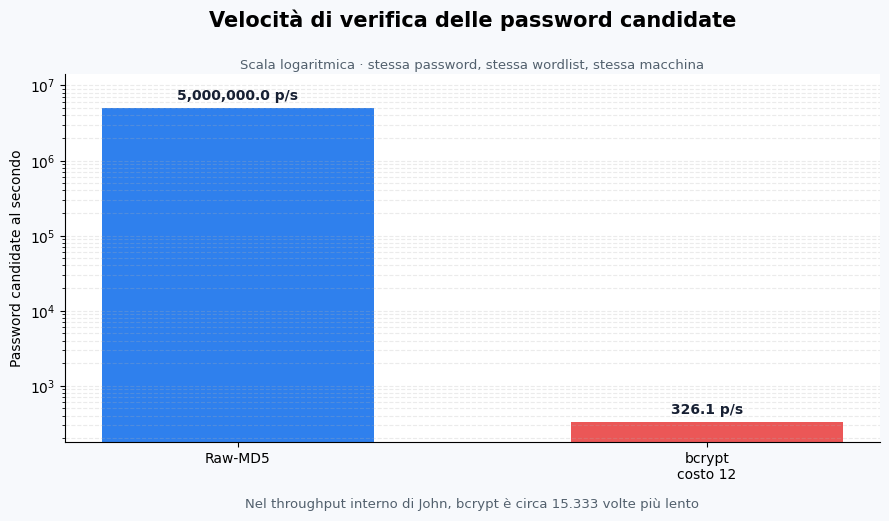

In [45]:
# Seleziona le velocità p/s realmente estratte da John.
speed_values = [md5_rate, bcrypt_rate]

# Definisce le etichette dei due formati.
speed_labels = ["Raw-MD5", f"bcrypt\ncosto {BCRYPT_COST}"]

# Crea la figura e l'area del grafico.
fig, ax = plt.subplots(figsize=(9, 5.4))

# Imposta lo sfondo esterno.
fig.patch.set_facecolor(COLORS["background"])

# Imposta lo sfondo interno.
ax.set_facecolor("white")

# Disegna le barre con una codifica cromatica coerente.
bars = ax.bar(
    speed_labels,
    speed_values,
    color=[COLORS["md5"], COLORS["bcrypt"]],
    width=0.58,
)

# Applica la scala logaritmica all'asse verticale.
ax.set_yscale("log")

# Riserva spazio sopra la barra più alta per l'etichetta.
ax.set_ylim(min(speed_values) * 0.55, max(speed_values) * 2.8)

# Imposta il titolo principale.
ax.set_title(
    "Velocità di verifica delle password candidate",
    fontsize=15,
    weight="bold",
    pad=34,
)

# Aggiunge un sottotitolo separato dal titolo.
ax.text(
    0.5,
    1.015,
    "Scala logaritmica · stessa password, stessa wordlist, stessa macchina",
    transform=ax.transAxes,
    ha="center",
    fontsize=9.5,
    color=COLORS["muted"],
)

# Etichetta l'asse verticale con la stessa metrica dei dati.
ax.set_ylabel("Password candidate al secondo")

# Aggiunge una griglia discreta.
ax.grid(axis="y", which="both", linestyle="--", alpha=0.25)

# Rimuove i bordi superiore e destro.
ax.spines[["top", "right"]].set_visible(False)

# Analizza ogni barra insieme al rispettivo valore.
for bar, value in zip(bars, speed_values):
    # Scrive il valore p/s sopra la barra.
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value * 1.18,
        f"{value:,.1f} p/s",
        ha="center",
        va="bottom",
        fontsize=10,
        weight="bold",
        color=COLORS["dark"],
    )

# Aggiunge la conclusione quantitativa sotto il grafico.
ax.text(
    0.5,
    -0.18,
    f"Nel throughput interno di John, bcrypt è circa {rate_ratio:,.0f} volte più lento",
    transform=ax.transAxes,
    ha="center",
    fontsize=9.5,
    color=COLORS["muted"],
)

# Ottimizza automaticamente gli spazi.
plt.tight_layout()

# Salva una copia ad alta risoluzione.
fig.savefig(
    DIRECTORIES["figures"] / "baseline_velocita.png",
    dpi=180,
    bbox_inches="tight",
)

# Mostra il grafico direttamente nel notebook.
plt.show()


### Interpretazione

Il grafico rappresenta il risultato centrale della baseline CPU. Gli stessi dati di ingresso vengono elaborati mediante due funzioni con costi di verifica profondamente diversi.

La scala logaritmica permette di leggere entrambe le barre senza ridurre bcrypt a un elemento visivamente impercettibile. La frase quantitativa sotto il grafico viene generata dal rapporto misurato.


## Tempo complessivo

Il secondo grafico mostra la durata realmente osservata dall’avvio alla conclusione del processo. È una misura intuitiva, ma deve essere letta ricordando che il tempo fisso di inizializzazione pesa soprattutto sulla prova MD5.

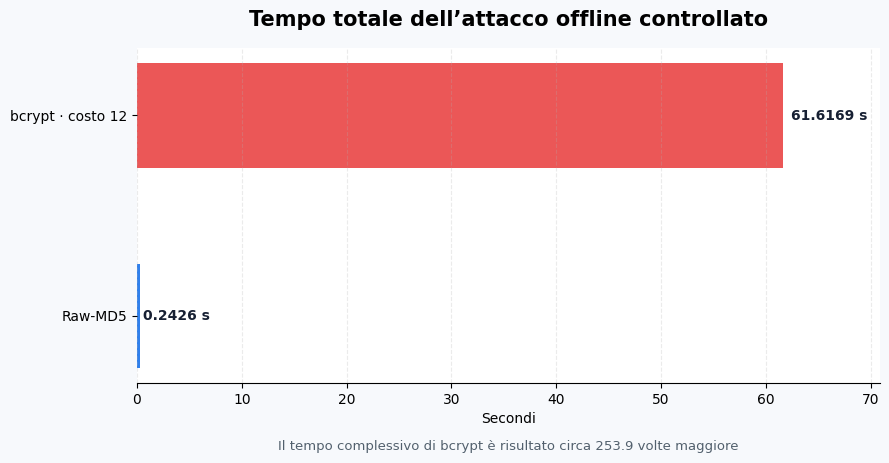

In [46]:
# Seleziona i tempi complessivi.
time_values = [md5_result["elapsed"], bcrypt_result["elapsed"]]

# Definisce le etichette.
time_labels = ["Raw-MD5", f"bcrypt · costo {BCRYPT_COST}"]

# Crea la figura.
fig, ax = plt.subplots(figsize=(9, 4.8))

# Imposta lo sfondo esterno.
fig.patch.set_facecolor(COLORS["background"])

# Imposta lo sfondo interno.
ax.set_facecolor("white")

# Disegna barre orizzontali per valorizzare la differenza.
bars = ax.barh(
    time_labels,
    time_values,
    color=[COLORS["md5"], COLORS["bcrypt"]],
    height=0.52,
)

# Imposta il titolo.
ax.set_title(
    "Tempo totale dell’attacco offline controllato",
    fontsize=15,
    weight="bold",
    pad=16,
)

# Etichetta l'asse orizzontale.
ax.set_xlabel("Secondi")

# Aggiunge la griglia.
ax.grid(axis="x", linestyle="--", alpha=0.25)

# Rimuove i bordi non necessari.
ax.spines[["top", "right", "left"]].set_visible(False)

# Analizza ogni barra insieme al valore corrispondente.
for bar, value in zip(bars, time_values):
    # Scrive il tempo alla destra della barra.
    ax.text(
        value + max(0.35, value * 0.012),
        bar.get_y() + bar.get_height() / 2,
        f"{value:.4f} s",
        va="center",
        fontsize=10,
        weight="bold",
        color=COLORS["dark"],
    )

# Riserva spazio per le etichette.
ax.set_xlim(0, max(time_values) * 1.15)

# Aggiunge il rapporto temporale.
ax.text(
    0.5,
    -0.20,
    f"Il tempo complessivo di bcrypt è risultato circa {time_ratio:,.1f} volte maggiore",
    transform=ax.transAxes,
    ha="center",
    fontsize=9.5,
    color=COLORS["muted"],
)

# Ottimizza gli spazi.
plt.tight_layout()

# Mostra il grafico.
fig.savefig(DIRECTORIES["figures"] / "baseline_tempi.png", dpi=180, bbox_inches="tight")
# Mostra la figura nel notebook.
plt.show()


### Interpretazione

La durata complessiva rende visibile l’effetto operativo del costo. Questo rapporto non sostituisce quello basato sul throughput perché il tempo fisso di inizializzazione incide in modo diverso sulle due prove.

Il valore riportato sotto il grafico viene calcolato dalla sessione corrente.


## Sostenibilità pratica su spazi più grandi

Per capire cosa succederebbe con liste più ampie, la tabella seguente divide il numero di candidate per il throughput `p/s` riportato da John.

È una stima del solo lavoro di verifica. Non include l’avvio del processo, il caricamento dei file e la chiusura. Per questo, soprattutto nel caso Raw-MD5 con liste molto brevi, il tempo stimato può essere molto più basso del tempo totale osservato.


In [47]:
# Definisce alcuni spazi di ricerca esemplificativi.
search_spaces = {
    "20 mila": 20_000,
    "1 milione": 1_000_000,
    "100 milioni": 100_000_000,
    "1 miliardo": 1_000_000_000,
}

# Definisce una funzione per formattare una durata in modo leggibile.
def human_duration(seconds: float) -> str:
    # Restituisce i microsecondi per durate estremamente brevi.
    if seconds < 0.001:
        # Converte i secondi in microsecondi.
        return f"{seconds * 1_000_000:.2f} µs"

    # Restituisce i millisecondi per durate inferiori al secondo.
    if seconds < 1:
        # Converte i secondi in millisecondi.
        return f"{seconds * 1_000:.2f} ms"

    # Restituisce i secondi per durate inferiori a un minuto.
    if seconds < 60:
        # Mantiene due decimali.
        return f"{seconds:.2f} s"

    # Restituisce i minuti per durate inferiori a un'ora.
    if seconds < 3_600:
        # Converte i secondi in minuti.
        return f"{seconds / 60:.2f} min"

    # Restituisce le ore per durate inferiori a un giorno.
    if seconds < 86_400:
        # Converte i secondi in ore.
        return f"{seconds / 3_600:.2f} h"

    # Restituisce i giorni per durate inferiori a un anno.
    if seconds < 31_536_000:
        # Converte i secondi in giorni.
        return f"{seconds / 86_400:.2f} giorni"

    # Restituisce gli anni per durate molto lunghe.
    return f"{seconds / 31_536_000:.2f} anni"

# Prepara la lista delle righe.
projection_rows = []

# Analizza ogni spazio di ricerca.
for label, size in search_spaces.items():
    # Calcola il tempo teorico per Raw-MD5.
    md5_seconds = size / md5_rate

    # Calcola il tempo teorico per bcrypt.
    bcrypt_seconds = size / bcrypt_rate

    # Aggiunge la riga alla tabella.
    projection_rows.append(
        {
            "Spazio": label,
            "Candidate": size,
            "Raw-MD5": human_duration(md5_seconds),
            "bcrypt costo 12": human_duration(bcrypt_seconds),
        }
    )

# Costruisce il DataFrame.
projection = pd.DataFrame(projection_rows)

# Visualizza la tabella formattata.
display(
    projection.style
    .format({"Candidate": "{:,.0f}"})
    .hide(axis="index")
)


Spazio,Candidate,Raw-MD5,bcrypt costo 12
20 mila,"20,000",4.00 ms,1.02 min
1 milione,"1,000,000",200.00 ms,51.11 min
100 milioni,"100,000,000",20.00 s,3.55 giorni
1 miliardo,"1,000,000,000",3.33 min,35.49 giorni


### Interpretazione

Il parametro di costo non rende sicura una password prevedibile, ma riduce il numero di tentativi che possono essere eseguiti nello stesso tempo.

I valori della tabella sono proiezioni lineari basate sul throughput interno di John nella sessione corrente. Servono a confrontare gli ordini di grandezza, non a prevedere con precisione qualsiasi attacco reale. Hardware, regole, numero di hash e costi fissi possono cambiare il risultato.


# 7. Ruolo del salt

Il salt non deve essere confuso con una chiave segreta. Viene normalmente memorizzato insieme all’hash. Il suo vantaggio è impedire che lo stesso calcolo possa essere riutilizzato contro utenti diversi e rendere inefficaci le tabelle precompute universali.

La cella seguente genera due hash bcrypt della stessa password. I risultati devono essere diversi, ma entrambe le verifiche devono restituire `True`.

In [48]:
# Genera due salt indipendenti con lo stesso costo.
salt_a = bcrypt.gensalt(rounds=BCRYPT_COST)
# Calcola e memorizza `salt_b`.
salt_b = bcrypt.gensalt(rounds=BCRYPT_COST)
# Calcola e memorizza `hash_a`.
hash_a = bcrypt.hashpw(password_bytes, salt_a)
# Calcola e memorizza `hash_b`.
hash_b = bcrypt.hashpw(password_bytes, salt_b)

# Verifica la stessa password contro entrambi i valori.
verify_a = bcrypt.checkpw(password_bytes, hash_a)
# Calcola e memorizza `verify_b`.
verify_b = bcrypt.checkpw(password_bytes, hash_b)

# Mostra impronte brevi invece degli hash completi.
fingerprint_a = hashlib.sha256(hash_a).hexdigest()[:16]
# Calcola e memorizza `fingerprint_b`.
fingerprint_b = hashlib.sha256(hash_b).hexdigest()[:16]

# Mostra il valore nel riepilogo della cella.
print("=== DIMOSTRAZIONE DEL SALT ===")
# Mostra il valore nel riepilogo della cella.
print(f"Impronta A       {fingerprint_a}")
# Mostra il valore nel riepilogo della cella.
print(f"Impronta B       {fingerprint_b}")
# Mostra il valore nel riepilogo della cella.
print(f"Impronte diverse {fingerprint_a != fingerprint_b}")
# Mostra il valore nel riepilogo della cella.
print(f"Verifica A       {verify_a}")
# Mostra il valore nel riepilogo della cella.
print(f"Verifica B       {verify_b}")

# Verifica la condizione prima di eseguire il blocco seguente.
if hash_a == hash_b or not verify_a or not verify_b:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError("La dimostrazione del salt non ha prodotto l'esito atteso.")


=== DIMOSTRAZIONE DEL SALT ===
Impronta A       2df99491de099800
Impronta B       baa72fb02ca5a306
Impronte diverse True
Verifica A       True
Verifica B       True


### Risultato atteso e significato

La cella deve mostrare due impronte diverse e due verifiche positive. Il salt modifica l’output senza modificare la password sottostante.

Per un singolo hash il salt non aumenta drasticamente il tempo di una singola prova. Il suo ruolo emerge su larga scala perché ogni salt richiede una derivazione distinta e impedisce di confrontare un unico risultato precomputato con molti account.


# 8. Ruolo del parametro di costo

In bcrypt il costo cresce in modo esponenziale. Aumentarlo di una unità raddoppia, in prima approssimazione, il lavoro della fase costosa. La cella seguente misura il tempo mediano necessario per calcolare un hash con costi 8, 10, 12 e 14 sulla macchina locale.

La generazione del salt avviene prima del cronometro. La misura riguarda quindi `bcrypt.hashpw`, cioè il passaggio computazionalmente rilevante.

Questa prova usa Python per mostrare l’effetto del parametro di costo e non sostituisce l’attacco eseguito con John. Può essere attivata o disattivata soltanto dalla dashboard iniziale.


In [49]:
# Prepara sempre un risultato definito.
cost_results = pd.DataFrame()

# Verifica la condizione prima di eseguire il blocco seguente.
if RUN_BCRYPT_COST_STUDY:
    # Definisce i costi da confrontare.
    cost_values = [8, 10, 12, 14]

    # Definisce il numero di ripetizioni per ciascun costo.
    repetitions = 3

    # Prepara la lista dei risultati.
    cost_records = []

    # Analizza ogni valore di costo.
    for cost in cost_values:
        # Prepara la lista dei tempi del costo corrente.
        timings = []

        # Ripete la misura per ridurre il peso della variabilità.
        for _ in range(repetitions):
            # Genera un nuovo salt per il costo corrente.
            salt = bcrypt.gensalt(rounds=cost)

            # Registra l'istante iniziale.
            start = time.perf_counter()

            # Calcola l'hash bcrypt.
            bcrypt.hashpw(password_bytes, salt)

            # Registra il tempo trascorso.
            elapsed = time.perf_counter() - start

            # Salva la misura.
            timings.append(elapsed)

        # Calcola la mediana delle ripetizioni.
        median_time = float(pd.Series(timings).median())

        # Aggiunge il risultato.
        cost_records.append(
            {
                "Costo": cost,
                "Fattore di lavoro 2^costo": 2**cost,
                "Tempo mediano (s)": median_time,
            }
        )

    # Costruisce la tabella.
    cost_results = pd.DataFrame(cost_records)

    # Visualizza la tabella.
    display(
        cost_results.style
        .format(
            {
                "Fattore di lavoro 2^costo": "{:,.0f}",
                "Tempo mediano (s)": "{:.4f}",
            }
        )
        .hide(axis="index")
    )

    # Crea una nuova figura.
    fig, ax = plt.subplots(figsize=(8.5, 4.8))

    # Imposta lo sfondo esterno.
    fig.patch.set_facecolor(COLORS["background"])

    # Disegna la curva dei tempi.
    ax.plot(
        cost_results["Costo"],
        cost_results["Tempo mediano (s)"],
        marker="o",
        linewidth=2.5,
        color=COLORS["bcrypt"],
    )

    # Imposta il titolo.
    ax.set_title("Crescita del costo computazionale di bcrypt", fontsize=14, weight="bold")

    # Etichetta l'asse orizzontale.
    ax.set_xlabel("Parametro di costo")

    # Etichetta l'asse verticale.
    ax.set_ylabel("Tempo mediano per hash (s)")

    # Aggiunge la griglia.
    ax.grid(linestyle="--", alpha=0.25)

    # Rimuove i bordi non necessari.
    ax.spines[["top", "right"]].set_visible(False)

    # Ottimizza gli spazi.
    plt.tight_layout()

    # Mostra il grafico.
    fig.savefig(DIRECTORIES["figures"] / "bcrypt_costo.png", dpi=180, bbox_inches="tight")
    # Mostra la figura nel notebook.
    plt.show()

    # Aggiorna il checkpoint della sessione.
    save_checkpoint(
        "CURVA_COSTO_BCRYPT_COMPLETATA",
        {
            "costs": cost_results["Costo"].tolist(),
            "median_seconds": cost_results["Tempo mediano (s)"].tolist(),
        },
    )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Studio del costo bcrypt non eseguito",
        "La prova è stata disattivata nella dashboard di controllo.",
        COLORS["accent"],
    )


### Lettura del risultato

La curva deve crescere rapidamente e non in modo lineare. Il costo costituisce una leva adattiva e può essere aumentato nel tempo per compensare l’evoluzione dell’hardware mantenendo accettabile la latenza per l’utente legittimo.

Un valore più alto non è automaticamente migliore in ogni contesto. Un sistema reale deve bilanciare sicurezza, latenza e capacità del servizio.


# 9. Benchmark CPU dedicati

Gli attacchi con wordlist includono caricamento dei file, avvio e chiusura del processo. Il comando `--test` esegue invece un benchmark interno per un intervallo definito e produce una misura più stabile del throughput sostenuto.

Il benchmark CPU può essere attivato o disattivato dalla dashboard iniziale. Quando è attivo, i benchmark CPU e GPU impiegano la stessa durata. Per bcrypt il vettore integrato di John usa costo 5 e non deve essere confuso con l’hash sperimentale a costo 12. La misura serve a caratterizzare l’implementazione e a costruire un confronto omogeneo tra i due backend.


In [50]:
# Prepara sempre contenitori compatibili con le analisi successive.
benchmark_outputs = {}
# Calcola e memorizza `cpu_benchmark_rates`.
cpu_benchmark_rates = {}

# Verifica la condizione prima di eseguire il blocco seguente.
if RUN_CPU_BENCHMARKS:
    # Definisce benchmark di uguale durata per i due formati CPU.
    benchmark_commands = {
        "Raw-MD5": [JOHN_EXE, "--format=Raw-MD5", f"--test={BENCHMARK_SECONDS}"],
        "bcrypt": [JOHN_EXE, "--format=bcrypt", f"--test={BENCHMARK_SECONDS}"],
    }
    # Ripete il blocco per ogni elemento della raccolta.
    for name, command in benchmark_commands.items():
        # Calcola e memorizza `returncode`, `output`.
        returncode, output = run_command(
            command,
            timeout=BENCHMARK_SECONDS + 45,
        )
        # Verifica la condizione prima di eseguire il blocco seguente.
        if returncode != 0 or john_output_has_fatal_error(output):
            # Interrompe l'esecuzione con un messaggio esplicativo.
            raise RuntimeError(
                f"Il benchmark CPU {name} non è valido.\n{output}"
            )
        # Calcola e memorizza `rate`, `label`.
        rate, label = parse_benchmark_rate(output)
        # Verifica la condizione prima di eseguire il blocco seguente.
        if rate is None:
            # Interrompe l'esecuzione con un messaggio esplicativo.
            raise RuntimeError(f"Il benchmark CPU {name} non espone una misura.")
        # Memorizza il risultato dell'operazione corrente.
        benchmark_outputs[name] = output
        # Memorizza il risultato dell'operazione corrente.
        cpu_benchmark_rates[name] = rate
        # Mostra il valore nel riepilogo della cella.
        print(f"\n=== BENCHMARK CPU {name.upper()} ===")
        # Mostra il valore nel riepilogo della cella.
        print(output)
        # Mostra il valore nel riepilogo della cella.
        print(f"Velocità acquisita     {rate:,.0f} c/s")

    # Aggiorna il checkpoint della sessione.
    save_checkpoint(
        "BENCHMARK_CPU_COMPLETATI",
        {
            "seconds": BENCHMARK_SECONDS,
            "raw_md5_cps": cpu_benchmark_rates["Raw-MD5"],
            "bcrypt_cost5_cps": cpu_benchmark_rates["bcrypt"],
        },
    )

    # Applica la pausa di raffreddamento prevista.
    cooldown_pause(
        CPU_COOLDOWN_SECONDS,
        "La pausa separa i benchmark CPU dalle sezioni intensive opzionali.",
    )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Benchmark CPU dedicati non eseguiti",
        "La prova è stata disattivata nella dashboard di controllo.",
        COLORS["accent"],
    )


### Interpretazione dei benchmark

Raw-MD5 deve mostrare un throughput molto superiore a quello osservato nella breve wordlist perché il benchmark ammortizza i costi fissi.

Il benchmark bcrypt usa costo 5 e può essere interpretato soltanto rispetto allo stesso vettore su un’altra piattaforma. Non è corretto confrontarlo direttamente con l’attacco a costo 12. Le velocità effettive vengono estratte automaticamente e salvate nel checkpoint della sessione.


# 10. Benchmark del parallelismo CPU

## Obiettivo

Questa sezione aggiuntiva studia la scalabilità OpenMP senza alterare la baseline. È disattivata durante l’esecuzione ordinaria per evitare una lunga sequenza di carichi intensivi. L’abilitazione avviene esclusivamente dalla dashboard iniziale.

Quando viene abilitata varia soltanto `OMP_NUM_THREADS`. Vengono effettuate tre ripetizioni brevi per ogni configurazione e viene conservata la mediana.

Le misure calcolate sono il throughput, lo speedup rispetto a un thread e l’efficienza parallela. Lo speedup ideale sarebbe lineare. Sincronizzazione, frequenza dinamica della CPU e parti non parallelizzabili producono rendimenti decrescenti.


In [51]:
# Prepara sempre un risultato definito.
parallel_results = pd.DataFrame()

# Verifica la condizione prima di eseguire il blocco seguente.
if RUN_CPU_SCALABILITY:
    # Importa statistics.
    import statistics

    # Calcola e memorizza `logical_cpus`.
    logical_cpus = psutil.cpu_count(logical=True) or 1
    # Calcola e memorizza `thread_plan`.
    thread_plan = sorted(
        {
            1,
            min(4, logical_cpus),
            max(1, logical_cpus // 2),
            logical_cpus,
        }
    )
    # Calcola e memorizza `PARALLEL_BENCHMARK_SECONDS`.
    PARALLEL_BENCHMARK_SECONDS = 2
    # Calcola e memorizza `PARALLEL_REPEATS`.
    PARALLEL_REPEATS = 3
    # Calcola e memorizza `parallel_records`.
    parallel_records = []

    # Ripete il blocco per ogni elemento della raccolta.
    for threads in thread_plan:
        # Calcola e memorizza `rates`.
        rates = []
        # Ripete il blocco per ogni elemento della raccolta.
        for repetition in range(PARALLEL_REPEATS):
            # Calcola e memorizza `benchmark_env`.
            benchmark_env = os.environ.copy()
            # Memorizza il risultato dell'operazione corrente.
            benchmark_env["OMP_NUM_THREADS"] = str(threads)
            # Memorizza il risultato dell'operazione corrente.
            benchmark_env["OMP_DYNAMIC"] = "FALSE"
            # Calcola e memorizza `command`.
            command = [
                JOHN_EXE,
                "--format=bcrypt",
                f"--test={PARALLEL_BENCHMARK_SECONDS}",
            ]
            # Calcola e memorizza `returncode`, `output`.
            returncode, output = run_command(
                command,
                env=benchmark_env,
                timeout=PARALLEL_BENCHMARK_SECONDS + 30,
            )
            # Verifica la condizione prima di eseguire il blocco seguente.
            if returncode != 0 or john_output_has_fatal_error(output):
                # Interrompe l'esecuzione con un messaggio esplicativo.
                raise RuntimeError(
                    f"Benchmark non valido con {threads} thread."
                )
            # Aggiunge il risultato alla raccolta corrente.
            rates.append(parse_benchmark_real_rate(output))

        # Aggiunge il risultato alla raccolta corrente.
        parallel_records.append(
            {
                "Thread": threads,
                "c/s real mediani": statistics.median(rates),
            }
        )
        # Applica la pausa di raffreddamento prevista.
        cooldown_pause(
            5,
            f"Raffreddamento dopo la configurazione con {threads} thread.",
        )

    # Calcola e memorizza `parallel_results`.
    parallel_results = pd.DataFrame(parallel_records)
    # Calcola e memorizza `single_thread_rate`.
    single_thread_rate = float(
        parallel_results.loc[
            parallel_results["Thread"] == 1,
            "c/s real mediani",
        ].iloc[0]
    )
    # Memorizza il risultato dell'operazione corrente.
    parallel_results["Speedup"] = (
        parallel_results["c/s real mediani"] / single_thread_rate
    )
    # Memorizza il risultato dell'operazione corrente.
    parallel_results["Efficienza"] = (
        parallel_results["Speedup"] / parallel_results["Thread"]
    )

    # Visualizza il risultato formattato nel notebook.
    display(
        parallel_results.style
        .format(
            {
                "c/s real mediani": "{:,.0f}",
                "Speedup": "{:.2f} volte",
                "Efficienza": "{:.1%}",
            }
        )
        .hide(axis="index")
    )

    # Aggiorna il checkpoint della sessione.
    save_checkpoint(
        "SCALABILITA_CPU_COMPLETATA",
        {
            "threads": parallel_results["Thread"].tolist(),
            "rates": parallel_results["c/s real mediani"].tolist(),
            "speedup": parallel_results["Speedup"].tolist(),
        },
    )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Scalabilità CPU non eseguita",
        "La sezione è opzionale e rimane disattivata durante la baseline.",
        COLORS["accent"],
    )


## Grafici di scalabilità

Il primo grafico mostra il throughput assoluto e lo confronta con la crescita lineare ideale.

Il vecchio grafico dello speedup aveva la stessa forma perché divideva ogni valore del throughput per una costante. Non costituiva quindi una seconda evidenza indipendente.

Il nuovo secondo grafico mostra l’efficienza parallela percentuale. Questa misura confronta lo speedup osservato con il numero di thread e rende visibile la perdita di rendimento dovuta a sincronizzazione, frequenza dinamica e parti non parallelizzabili.


In [52]:
# Verifica la condizione prima di eseguire il blocco seguente.
if parallel_results.empty:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Grafici di scalabilità in attesa",
        "Abilitare la prova opzionale per generare le due figure.",
        COLORS["accent"],
    )
# Gestisce il caso alternativo.
else:
    # Calcola e memorizza `ideal_throughput`.
    ideal_throughput = (
        parallel_results["Thread"]
        * float(parallel_results["c/s real mediani"].iloc[0])
    )

    # Calcola e memorizza `fig`, `ax`.
    fig, ax = plt.subplots(figsize=(8.8, 4.8))
    # Imposta il colore di sfondo previsto.
    fig.patch.set_facecolor(COLORS["background"])
    # Disegna la curva con i dati calcolati.
    ax.plot(
        parallel_results["Thread"],
        parallel_results["c/s real mediani"],
        marker="o",
        linewidth=2.5,
        label="Misurato",
        color=COLORS["bcrypt"],
    )
    # Disegna la curva con i dati calcolati.
    ax.plot(
        parallel_results["Thread"],
        ideal_throughput,
        linestyle="--",
        linewidth=1.8,
        label="Ideale lineare",
        color=COLORS["muted"],
    )
    # Imposta il titolo del grafico.
    ax.set_title(
        "Scalabilità CPU del benchmark bcrypt",
        fontsize=14,
        weight="bold",
    )
    # Etichetta l'asse orizzontale.
    ax.set_xlabel("Thread OpenMP")
    # Etichetta l'asse verticale.
    ax.set_ylabel("Calcoli al secondo")
    # Aggiunge una griglia discreta al grafico.
    ax.grid(linestyle="--", alpha=0.25)
    # Mostra la legenda del grafico.
    ax.legend(frameon=False)
    # Nasconde i bordi grafici non necessari.
    ax.spines[["top", "right"]].set_visible(False)
    # Ottimizza automaticamente gli spazi della figura.
    plt.tight_layout()
    # Salva la figura ad alta risoluzione.
    fig.savefig(
        DIRECTORIES["figures"] / "scalabilita_throughput.png",
        dpi=180,
        bbox_inches="tight",
    )
    # Mostra la figura nel notebook.
    plt.show()

    # Calcola e memorizza `efficiency_percent`.
    efficiency_percent = parallel_results["Efficienza"] * 100
    # Calcola e memorizza `fig`, `ax`.
    fig, ax = plt.subplots(figsize=(8.8, 4.8))
    # Imposta il colore di sfondo previsto.
    fig.patch.set_facecolor(COLORS["background"])
    # Calcola e memorizza `bars`.
    bars = ax.bar(
        parallel_results["Thread"].astype(str),
        efficiency_percent,
        color=COLORS["md5"],
        width=0.58,
    )
    # Traccia la linea orizzontale di riferimento.
    ax.axhline(
        100,
        linestyle="--",
        linewidth=1.8,
        color=COLORS["muted"],
        label="Efficienza ideale",
    )
    # Imposta il titolo del grafico.
    ax.set_title(
        "Efficienza parallela osservata",
        fontsize=14,
        weight="bold",
    )
    # Etichetta l'asse orizzontale.
    ax.set_xlabel("Thread OpenMP")
    # Etichetta l'asse verticale.
    ax.set_ylabel("Efficienza percentuale")
    # Aggiunge una griglia discreta al grafico.
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    # Mostra la legenda del grafico.
    ax.legend(frameon=False)
    # Nasconde i bordi grafici non necessari.
    ax.spines[["top", "right"]].set_visible(False)
    # Imposta i limiti dell'asse verticale.
    ax.set_ylim(0, max(110, float(efficiency_percent.max()) * 1.16))
    # Ripete il blocco per ogni elemento della raccolta.
    for bar, value in zip(bars, efficiency_percent):
        # Aggiunge un'etichetta esplicativa al grafico.
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            weight="bold",
        )
    # Ottimizza automaticamente gli spazi della figura.
    plt.tight_layout()
    # Salva la figura ad alta risoluzione.
    fig.savefig(
        DIRECTORIES["figures"] / "scalabilita_efficienza.png",
        dpi=180,
        bbox_inches="tight",
    )
    # Mostra la figura nel notebook.
    plt.show()


### Come interpretare la prova

Un aumento del throughput conferma che più candidate possono essere verificate in parallelo. Lo speedup misurato deve essere confrontato con la crescita lineare ideale senza assumere che il numero di thread coincida con il guadagno effettivo.

Il parallelismo aumenta il throughput ma non annulla il costo di bcrypt. Ogni candidata continua a richiedere il lavoro determinato dal parametro incorporato nell’hash.


# 11. Appendice GPU con OpenCL

La baseline ufficiale resta il confronto CPU tra Raw-MD5 e bcrypt. L’appendice GPU è separata e serve a osservare quanto il parallelismo possa accelerare i calcoli, soprattutto per un hash veloce.

La GPU usata è una NVIDIA GeForce RTX 5070 Ti Laptop basata su architettura Blackwell. La documentazione NVIDIA indica 5.888 CUDA core, 12 GB di memoria GDDR7 e una potenza del sottosistema GPU compresa tra 60 e 115 W. Il valore effettivo dipende dal modello di portatile, dal profilo energetico e dalla temperatura.

John the Ripper viene usato per individuare il dispositivo OpenCL corretto. Il conteggio mostrato dal runtime non viene interpretato come numero ufficiale di CUDA core, perché descrive il dispositivo con una convenzione diversa.

Il benchmark `--test` e l’attacco con wordlist misurano due situazioni differenti. Il primo attenua il peso dell’avvio e osserva il throughput del backend. Il secondo comprende anche inizializzazione OpenCL, preparazione del kernel, buffer e sincronizzazione.


## Diagnostica OpenCL e selezione del dispositivo

La diagnostica viene eseguita soltanto se nella dashboard è attiva almeno una prova GPU. Se entrambe le prove GPU sono disattivate, la cella prepara valori vuoti e non interroga né OpenCL né `nvidia-smi`.

Quando serve, la cella cerca una sola corrispondenza esatta con `NVIDIA GeForce RTX 5070 Ti Laptop GPU` e ricava l’indice direttamente dall’output di John. Prima di ogni carico controlla inoltre modello, alimentazione e temperatura. Se il sistema segnala che il portatile è a batteria, oppure se la temperatura non può essere verificata, la prova non parte.


In [53]:
# Definisce l'unico modello ammesso dal protocollo.
EXPECTED_GPU_MODEL = "NVIDIA GeForce RTX 5070 Ti Laptop GPU"

# Verifica se la dashboard richiede almeno una prova GPU.
GPU_WORK_REQUESTED = RUN_GPU_BENCHMARKS or RUN_GPU_WORDLIST_ATTACKS

# Prepara valori sicuri anche quando la diagnostica non viene eseguita.
OPENCL_DEVICE = None
# Calcola e memorizza `opencl_devices`.
opencl_devices = []
# Calcola e memorizza `raw_md5_opencl_available`.
raw_md5_opencl_available = False
# Calcola e memorizza `bcrypt_opencl_available`.
bcrypt_opencl_available = False
# Calcola e memorizza `opencl_runtime_available`.
opencl_runtime_available = False
# Calcola e memorizza `nvidia_status`.
nvidia_status = None

# Cerca nvidia-smi nel sistema senza avviarlo.
NVIDIA_SMI = shutil.which("nvidia-smi")


# Converte un campo numerico di nvidia-smi gestendo i valori non disponibili.
def parse_optional_float(value):
    # Calcola e memorizza `cleaned`.
    cleaned = value.strip()
    # Verifica la condizione prima di eseguire il blocco seguente.
    if cleaned in {"", "N/A", "[N/A]", "Not Supported"}:
        # Restituisce il risultato al chiamante.
        return None
    # Gestisce in modo controllato le possibili eccezioni.
    try:
        # Restituisce il risultato al chiamante.
        return float(cleaned)
    # Gestisce l'eccezione prevista.
    except ValueError:
        # Restituisce il risultato al chiamante.
        return None


# Acquisisce lo stato corrente della GPU NVIDIA.
def read_nvidia_status():
    # Verifica la condizione prima di eseguire il blocco seguente.
    if NVIDIA_SMI is None:
        # Restituisce il risultato al chiamante.
        return None

    # Calcola e memorizza `query_sets`.
    query_sets = [
        (
            "name,driver_version,memory.total,temperature.gpu,"
            "power.draw,power.limit"
        ),
        "name,driver_version,memory.total,temperature.gpu",
    ]
    # Ripete il blocco per ogni elemento della raccolta.
    for fields in query_sets:
        # Calcola e memorizza `returncode`, `output`.
        returncode, output = run_command(
            [
                NVIDIA_SMI,
                f"--query-gpu={fields}",
                "--format=csv,noheader,nounits",
            ],
            timeout=15,
        )
        # Verifica la condizione prima di eseguire il blocco seguente.
        if returncode != 0:
            # Passa all'iterazione successiva.
            continue
        # Ripete il blocco per ogni elemento della raccolta.
        for line in output.splitlines():
            # Calcola e memorizza `parts`.
            parts = [part.strip() for part in line.split(",")]
            # Verifica la condizione prima di eseguire il blocco seguente.
            if parts and parts[0] == EXPECTED_GPU_MODEL:
                # Restituisce il risultato al chiamante.
                return {
                    "Modello": parts[0],
                    "Driver": parts[1] if len(parts) > 1 else None,
                    "Memoria totale MB": (
                        parse_optional_float(parts[2])
                        if len(parts) > 2
                        else None
                    ),
                    "Temperatura C": (
                        parse_optional_float(parts[3])
                        if len(parts) > 3
                        else None
                    ),
                    "Potenza W": (
                        parse_optional_float(parts[4])
                        if len(parts) > 4
                        else None
                    ),
                    "Limite potenza W": (
                        parse_optional_float(parts[5])
                        if len(parts) > 5
                        else None
                    ),
                }
    # Restituisce il risultato al chiamante.
    return None


# Attende una temperatura adatta prima di iniziare un carico.
def wait_for_gpu_ready():
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not GPU_WORK_REQUESTED:
        # Restituisce il risultato al chiamante.
        return False

    # Verifica la condizione prima di eseguire il blocco seguente.
    if POWER_PLUGGED is False:
        # Mostra un pannello esplicativo nel notebook.
        show_panel(
            "Prova GPU bloccata",
            "Collegare il computer alla rete elettrica prima del benchmark.",
            COLORS["accent"],
        )
        # Restituisce il risultato al chiamante.
        return False

    # Calcola e memorizza `deadline`.
    deadline = time.time() + GPU_MAX_WAIT_SECONDS
    # Continua il ciclo finché la condizione rimane vera.
    while time.time() <= deadline:
        # Calcola e memorizza `status`.
        status = read_nvidia_status()
        # Verifica la condizione prima di eseguire il blocco seguente.
        if status is None:
            # Mostra un pannello esplicativo nel notebook.
            show_panel(
                "Telemetria GPU non disponibile",
                "La prova resta bloccata perché la temperatura non può essere verificata.",
                COLORS["accent"],
            )
            # Restituisce il risultato al chiamante.
            return False
        # Calcola e memorizza `temperature`.
        temperature = status["Temperatura C"]
        # Verifica la condizione prima di eseguire il blocco seguente.
        if temperature is None:
            # Mostra un pannello esplicativo nel notebook.
            show_panel(
                "Temperatura GPU non disponibile",
                "La prova resta bloccata perché il sensore non ha restituito un valore.",
                COLORS["accent"],
            )
            # Restituisce il risultato al chiamante.
            return False
        # Verifica la condizione prima di eseguire il blocco seguente.
        if temperature is not None and temperature <= GPU_START_TEMPERATURE_C:
            # Restituisce il risultato al chiamante.
            return True
        # Mostra il valore nel riepilogo della cella.
        print(
            f"GPU a {temperature:.0f} °C  attesa prima della prova"
            if temperature is not None
            else "Temperatura GPU non disponibile"
        )
        # Attende l'intervallo di raffreddamento previsto.
        time.sleep(10)

    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Prova GPU rinviata",
        "La temperatura non è scesa entro il tempo massimo di attesa.",
        COLORS["accent"],
    )
    # Restituisce il risultato al chiamante.
    return False


# Attende il raffreddamento dopo un carico GPU.
def cooldown_gpu():
    # Calcola e memorizza `deadline`.
    deadline = time.time() + GPU_MAX_WAIT_SECONDS
    # Continua il ciclo finché la condizione rimane vera.
    while time.time() <= deadline:
        # Calcola e memorizza `status`.
        status = read_nvidia_status()
        # Verifica la condizione prima di eseguire il blocco seguente.
        if status is None:
            # Restituisce il risultato al chiamante.
            return
        # Calcola e memorizza `temperature`.
        temperature = status["Temperatura C"]
        # Verifica la condizione prima di eseguire il blocco seguente.
        if temperature is None:
            # Mostra il valore nel riepilogo della cella.
            print("Raffreddamento non verificabile perché manca la temperatura")
            # Restituisce il risultato al chiamante.
            return
        # Verifica la condizione prima di eseguire il blocco seguente.
        if (
            temperature is not None
            and temperature <= GPU_COOLDOWN_TEMPERATURE_C
        ):
            # Mostra il valore nel riepilogo della cella.
            print(f"Raffreddamento completato a {temperature:.0f} °C")
            # Restituisce il risultato al chiamante.
            return
        # Mostra il valore nel riepilogo della cella.
        print(
            f"Raffreddamento GPU  {temperature:.0f} °C"
            if temperature is not None
            else "Raffreddamento GPU in corso"
        )
        # Attende l'intervallo di raffreddamento previsto.
        time.sleep(10)
    # Mostra il valore nel riepilogo della cella.
    print("Tempo massimo di raffreddamento raggiunto")


# Restituisce l'opzione del dispositivo validato.
def opencl_device_arguments():
    # Verifica la condizione prima di eseguire il blocco seguente.
    if OPENCL_DEVICE is None:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError("La RTX 5070 Ti Laptop non è stata identificata.")
    # Restituisce il risultato al chiamante.
    return [f"--device={OPENCL_DEVICE}"]


# Esegue la diagnostica soltanto quando una prova GPU è stata richiesta.
if GPU_WORK_REQUESTED:
    # Calcola e memorizza `opencl_returncode`, `opencl_output`.
    opencl_returncode, opencl_output = run_command(
        [JOHN_EXE, "--list=opencl-devices"],
        timeout=30,
    )

    # Mostra il valore nel riepilogo della cella.
    print("=== DISPOSITIVI OPENCL RILEVATI ===")
    # Mostra il valore nel riepilogo della cella.
    print(opencl_output)

    # Calcola e memorizza `device_pattern`.
    device_pattern = re.compile(
        r"Device #(?P<local>\d+)"
        r"(?:\s+\((?P<global>\d+)\))?"
        r"\s+name:\s*(?P<name>[^\r\n]+)"
        r"(?P<body>.*?)(?=\n\s*Device #|\nPlatform #|\Z)",
        flags=re.IGNORECASE | re.DOTALL,
    )

    # Ripete il blocco per ogni elemento della raccolta.
    for match in device_pattern.finditer(opencl_output):
        # Calcola e memorizza `local_index`.
        local_index = int(match.group("local"))
        # Calcola e memorizza `global_index`.
        global_index = match.group("global")
        # Aggiunge il risultato alla raccolta corrente.
        opencl_devices.append(
            {
                "Indice locale": local_index,
                "Indice John": (
                    int(global_index)
                    if global_index is not None
                    else local_index + 1
                ),
                "Modello": match.group("name").strip(),
                "Dettagli": match.group("body"),
            }
        )

    # Calcola e memorizza `expected_matches`.
    expected_matches = [
        device
        for device in opencl_devices
        if device["Modello"] == EXPECTED_GPU_MODEL
    ]

    # Verifica la condizione prima di eseguire il blocco seguente.
    if len(expected_matches) != 1:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError(
            "La diagnostica deve trovare una sola RTX 5070 Ti Laptop GPU."
        )

    # Prepara l'indice del dispositivo OpenCL validato.
    OPENCL_DEVICE = expected_matches[0]["Indice John"]
    # Calcola e memorizza `formats_output_lower`.
    formats_output_lower = formats_output.lower()
    # Calcola e memorizza `raw_md5_opencl_available`.
    raw_md5_opencl_available = "raw-md5-opencl" in formats_output_lower
    # Calcola e memorizza `bcrypt_opencl_available`.
    bcrypt_opencl_available = "bcrypt-opencl" in formats_output_lower
    # Calcola e memorizza `opencl_runtime_available`.
    opencl_runtime_available = (
        opencl_returncode == 0
        and not john_output_has_fatal_error(opencl_output)
        and OPENCL_DEVICE is not None
    )

    # Verifica la condizione prima di eseguire il blocco seguente.
    if not opencl_runtime_available:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError("La RTX 5070 Ti Laptop non è disponibile tramite OpenCL.")
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not raw_md5_opencl_available or not bcrypt_opencl_available:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError(
            "La build di John deve includere Raw-MD5 OpenCL e bcrypt OpenCL."
        )

    # Visualizza il risultato formattato nel notebook.
    display(
        pd.DataFrame(opencl_devices)[
            ["Indice locale", "Indice John", "Modello"]
        ]
        .style
        .hide(axis="index")
    )

    # Calcola e memorizza `nvidia_status`.
    nvidia_status = read_nvidia_status()

    # Mostra il valore nel riepilogo della cella.
    print()
    # Mostra il valore nel riepilogo della cella.
    print("=== GPU AMMESSA DAL PROTOCOLLO ===")
    # Mostra il valore nel riepilogo della cella.
    print(f"Modello atteso           {EXPECTED_GPU_MODEL}")
    # Mostra il valore nel riepilogo della cella.
    print(f"Indice OpenCL John       {OPENCL_DEVICE}")
    # Mostra il valore nel riepilogo della cella.
    print(f"Runtime OpenCL valido    {opencl_runtime_available}")
    # Mostra il valore nel riepilogo della cella.
    print(f"Raw-MD5 OpenCL           {raw_md5_opencl_available}")
    # Mostra il valore nel riepilogo della cella.
    print(f"bcrypt OpenCL            {bcrypt_opencl_available}")

    # Verifica la condizione prima di eseguire il blocco seguente.
    if nvidia_status is not None:
        # Visualizza il risultato formattato nel notebook.
        display(pd.DataFrame([nvidia_status]).style.hide(axis="index"))

    # Aggiorna il checkpoint della sessione.
    save_checkpoint(
        "DIAGNOSTICA_GPU_COMPLETATA",
        {
            "model": EXPECTED_GPU_MODEL,
            "opencl_device": OPENCL_DEVICE,
            "opencl_available": opencl_runtime_available,
            "temperature_c": (
                nvidia_status["Temperatura C"]
                if nvidia_status is not None
                else None
            ),
        },
    )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Diagnostica GPU non eseguita",
        "Nessuna prova GPU è attiva nella dashboard. OpenCL e nvidia-smi non sono stati interrogati.",
        COLORS["accent"],
    )


## Benchmark GPU con OpenCL

La sezione è disattivata nel profilo Solo baseline. L’abilitazione avviene dalla dashboard iniziale e viene conservata anche dopo il riavvio del kernel.

Ogni benchmark usa il dispositivo che corrisponde esattamente alla RTX 5070 Ti Laptop. Il protocollo controlla la temperatura prima della prova, impone un timeout, registra la temperatura finale e attende il raffreddamento prima del carico successivo.

Il rapporto ottenuto confronta due backend durante prove dedicate e prolungate. Non rappresenta un fattore di accelerazione valido per ogni modalità di attacco.


In [54]:
# Esegue un benchmark OpenCL soltanto dopo il controllo termico.
def run_opencl_benchmark(label, format_name, seconds=BENCHMARK_SECONDS):
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not wait_for_gpu_ready():
        # Restituisce il risultato al chiamante.
        return {
            "Formato": label,
            "Formato John": format_name,
            "Codice uscita": None,
            "Velocità (c/s)": None,
            "Riga metrica": None,
            "Temperatura iniziale C": None,
            "Temperatura finale C": None,
            "Stato": "NON ESEGUITO",
            "Output": "",
            "Dispositivo corretto": False,
            "Successo": False,
        }

    # Calcola e memorizza `initial_status`.
    initial_status = read_nvidia_status()
    # Calcola e memorizza `command`.
    command = [
        JOHN_EXE,
        f"--format={format_name}",
        *opencl_device_arguments(),
        f"--test={seconds}",
    ]
    # Calcola e memorizza `returncode`, `output`.
    returncode, output = run_command(
        command,
        timeout=seconds + 45,
    )
    # Calcola e memorizza `final_status`.
    final_status = read_nvidia_status()
    # Calcola e memorizza `rate`, `rate_label`.
    rate, rate_label = parse_benchmark_rate(output)
    # Calcola e memorizza `fatal_error`.
    fatal_error = john_output_has_fatal_error(output)
    # Calcola e memorizza `expected_device_used`.
    expected_device_used = EXPECTED_GPU_MODEL in output
    # Calcola e memorizza `success`.
    success = (
        returncode == 0
        and rate is not None
        and not fatal_error
        and expected_device_used
    )
    # Calcola e memorizza `record`.
    record = {
        "Formato": label,
        "Formato John": format_name,
        "Codice uscita": returncode,
        "Velocità (c/s)": rate,
        "Riga metrica": rate_label,
        "Temperatura iniziale C": (
            initial_status["Temperatura C"]
            if initial_status is not None
            else None
        ),
        "Temperatura finale C": (
            final_status["Temperatura C"]
            if final_status is not None
            else None
        ),
        "Stato": "OK" if success else "ERRORE",
        "Output": output,
        "Dispositivo corretto": expected_device_used,
        "Successo": success,
    }
    # Esegue l'operazione necessaria per questo passaggio.
    cooldown_gpu()
    # Restituisce il risultato al chiamante.
    return record


# Calcola e memorizza `gpu_benchmark_records`.
gpu_benchmark_records = []

# Verifica la condizione prima di eseguire il blocco seguente.
if RUN_GPU_BENCHMARKS:
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not opencl_runtime_available:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError("Il runtime OpenCL validato non è disponibile.")
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not raw_md5_opencl_available or not bcrypt_opencl_available:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError(
            "I formati Raw-MD5 OpenCL e bcrypt OpenCL devono essere entrambi disponibili."
        )

    # Calcola e memorizza `benchmark_plan`.
    benchmark_plan = [
        ("Raw-MD5", "raw-MD5-opencl"),
        ("bcrypt · costo benchmark", "bcrypt-opencl"),
    ]

    # Ripete il blocco per ogni elemento della raccolta.
    for label, format_name in benchmark_plan:
        # Calcola e memorizza `record`.
        record = run_opencl_benchmark(label, format_name)
        # Aggiunge il risultato alla raccolta corrente.
        gpu_benchmark_records.append(record)
        # Mostra il valore nel riepilogo della cella.
        print(f"\n=== BENCHMARK GPU {label.upper()} ===")
        # Mostra il valore nel riepilogo della cella.
        print(redact_sensitive_text(record["Output"]))
        # Mostra il valore nel riepilogo della cella.
        print(f"Stato                  {record['Stato']}")
        # Mostra il valore nel riepilogo della cella.
        print(
            "Velocità               "
            + (
                f"{record['Velocità (c/s)']:,.0f} c/s"
                if record["Velocità (c/s)"] is not None
                else "non disponibile"
            )
        )

    # Verifica la condizione prima di eseguire il blocco seguente.
    if gpu_benchmark_records:
        # Calcola e memorizza `gpu_benchmark_table`.
        gpu_benchmark_table = pd.DataFrame(gpu_benchmark_records)[
            [
                "Formato",
                "Formato John",
                "Codice uscita",
                "Velocità (c/s)",
                "Temperatura iniziale C",
                "Temperatura finale C",
                "Dispositivo corretto",
                "Stato",
            ]
        ]
        # Visualizza il risultato formattato nel notebook.
        display(
            gpu_benchmark_table.style
            .format(
                {
                    "Velocità (c/s)": lambda value: (
                        f"{value:,.0f}" if pd.notna(value) else "n.d."
                    ),
                    "Temperatura iniziale C": lambda value: (
                        f"{value:.0f}" if pd.notna(value) else "n.d."
                    ),
                    "Temperatura finale C": lambda value: (
                        f"{value:.0f}" if pd.notna(value) else "n.d."
                    ),
                }
            )
            .hide(axis="index")
        )

    # Aggiorna il checkpoint della sessione.
    save_checkpoint(
        "BENCHMARK_GPU_COMPLETATI",
        {
            "seconds": BENCHMARK_SECONDS,
            "records": [
                {
                    "format": record["Formato"],
                    "success": bool(record["Successo"]),
                    "rate_cps": record["Velocità (c/s)"],
                    "initial_temperature_c": record["Temperatura iniziale C"],
                    "final_temperature_c": record["Temperatura finale C"],
                }
                for record in gpu_benchmark_records
            ],
        },
    )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Benchmark GPU non eseguito",
        "La sezione è pronta ma richiede l'abilitazione esplicita nella configurazione.",
        COLORS["accent"],
    )


## Confronto dei benchmark CPU e GPU

Il confronto usa misure prodotte con `--test` nella stessa sessione e con la stessa durata.

1. Raw-MD5 CPU viene confrontato con Raw-MD5 OpenCL

2. bcrypt CPU viene confrontato con bcrypt OpenCL usando in entrambi i casi il vettore integrato a costo 5

Lo speedup descrive le implementazioni complete disponibili nella build di John. Non rappresenta un rapporto puro tra unità hardware perché il backend OpenCL applica ottimizzazioni specifiche e il formato CPU Raw-MD5 non usa tutti i core mediante OpenMP.


In [55]:
# Prepara tabelle vuote utilizzabili anche quando il confronto è disattivato.
benchmark_platform_comparison = pd.DataFrame()
# Calcola e memorizza `benchmark_ratios`.
benchmark_ratios = pd.DataFrame(
    columns=["Formato", "Rapporto benchmark GPU/CPU"]
)

# Costruisce il confronto soltanto se entrambi i benchmark sono stati richiesti.
if RUN_CPU_BENCHMARKS and RUN_GPU_BENCHMARKS:
    # Calcola e memorizza `cpu_benchmark_reference`.
    cpu_benchmark_reference = {
        "Raw-MD5": cpu_benchmark_rates.get("Raw-MD5"),
        "bcrypt · costo benchmark": cpu_benchmark_rates.get("bcrypt"),
    }

    # Calcola e memorizza `gpu_benchmark_reference`.
    gpu_benchmark_reference = {
        record["Formato"]: record["Velocità (c/s)"]
        for record in gpu_benchmark_records
        if record["Successo"]
    }

    # Calcola e memorizza `benchmark_platform_rows`.
    benchmark_platform_rows = []
    # Calcola e memorizza `benchmark_ratio_rows`.
    benchmark_ratio_rows = []

    # Ripete il blocco per ogni elemento della raccolta.
    for format_label in ("Raw-MD5", "bcrypt · costo benchmark"):
        # Calcola e memorizza `cpu_value`.
        cpu_value = cpu_benchmark_reference.get(format_label)
        # Calcola e memorizza `gpu_value`.
        gpu_value = gpu_benchmark_reference.get(format_label)

        # Verifica la condizione prima di eseguire il blocco seguente.
        if cpu_value is not None:
            # Aggiunge il risultato alla raccolta corrente.
            benchmark_platform_rows.append(
                {
                    "Formato": format_label,
                    "Piattaforma": "CPU",
                    "Velocità (c/s)": cpu_value,
                }
            )

        # Verifica la condizione prima di eseguire il blocco seguente.
        if gpu_value is not None:
            # Aggiunge il risultato alla raccolta corrente.
            benchmark_platform_rows.append(
                {
                    "Formato": format_label,
                    "Piattaforma": "GPU/OpenCL",
                    "Velocità (c/s)": gpu_value,
                }
            )

        # Verifica la condizione prima di eseguire il blocco seguente.
        if cpu_value is not None and gpu_value is not None:
            # Aggiunge il risultato alla raccolta corrente.
            benchmark_ratio_rows.append(
                {
                    "Formato": format_label,
                    "Rapporto benchmark GPU/CPU": gpu_value / cpu_value,
                }
            )

    # Calcola e memorizza `benchmark_platform_comparison`.
    benchmark_platform_comparison = pd.DataFrame(benchmark_platform_rows)
    # Calcola e memorizza `benchmark_ratios`.
    benchmark_ratios = pd.DataFrame(benchmark_ratio_rows)

    # Verifica la condizione prima di eseguire il blocco seguente.
    if not benchmark_platform_comparison.empty:
        # Visualizza il risultato formattato nel notebook.
        display(
            benchmark_platform_comparison.style
            .format({"Velocità (c/s)": "{:,.0f}"})
            .hide(axis="index")
        )

    # Verifica la condizione prima di eseguire il blocco seguente.
    if not benchmark_ratios.empty:
        # Visualizza il risultato formattato nel notebook.
        display(
            benchmark_ratios.style
            .format({"Rapporto benchmark GPU/CPU": "{:.2f}×"})
            .hide(axis="index")
        )

        # Calcola e memorizza `fig`, `ax`.
        fig, ax = plt.subplots(figsize=(8.8, 4.8))
        # Imposta il colore di sfondo previsto.
        fig.patch.set_facecolor(COLORS["background"])
        # Calcola e memorizza `bars`.
        bars = ax.bar(
            benchmark_ratios["Formato"],
            benchmark_ratios["Rapporto benchmark GPU/CPU"],
            color=COLORS["gpu"],
            width=0.58,
        )
        # Traccia la linea orizzontale di riferimento.
        ax.axhline(
            1,
            linestyle="--",
            linewidth=1.4,
            color=COLORS["muted"],
            label="Parità CPU–GPU",
        )
        # Imposta il titolo del grafico.
        ax.set_title(
            "Rapporto di throughput tra benchmark GPU e CPU",
            fontsize=14,
            weight="bold",
            pad=14,
        )
        # Etichetta l'asse verticale.
        ax.set_ylabel("Rapporto tra benchmark")
        # Aggiunge una griglia discreta al grafico.
        ax.grid(axis="y", linestyle="--", alpha=0.25)
        # Mostra la legenda del grafico.
        ax.legend(frameon=False)
        # Nasconde i bordi grafici non necessari.
        ax.spines[["top", "right"]].set_visible(False)

        # Ripete il blocco per ogni elemento della raccolta.
        for bar, value in zip(
            bars,
            benchmark_ratios["Rapporto benchmark GPU/CPU"],
        ):
            # Aggiunge un'etichetta esplicativa al grafico.
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.2f}×",
                ha="center",
                va="bottom",
                weight="bold",
            )

        # Ottimizza automaticamente gli spazi della figura.
        plt.tight_layout()
        # Salva la figura ad alta risoluzione.
        fig.savefig(
            DIRECTORIES["figures"] / "benchmark_cpu_gpu_rapporto.png",
            dpi=180,
            bbox_inches="tight",
        )
        # Mostra la figura nel notebook.
        plt.show()

    # Verifica la condizione prima di eseguire il blocco seguente.
    if len(benchmark_ratios) != 2:
        # Mostra un pannello esplicativo nel notebook.
        show_panel(
            "Confronto benchmark incompleto",
            "Almeno uno dei quattro benchmark richiesti non ha prodotto una misura valida.",
            COLORS["accent"],
        )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Confronto benchmark CPU–GPU non richiesto",
        "Per costruire il rapporto occorre attivare insieme RUN_CPU_BENCHMARKS e RUN_GPU_BENCHMARKS nella dashboard.",
        COLORS["accent"],
    )


In [56]:
# Produce un commento metodologico per ogni confronto riuscito.
if not benchmark_ratios.empty:
    # Ripete il blocco per ogni elemento della raccolta.
    for _, row in benchmark_ratios.iterrows():
        # Calcola e memorizza `format_label`.
        format_label = row["Formato"]
        # Calcola e memorizza `ratio_value`.
        ratio_value = float(row["Rapporto benchmark GPU/CPU"])

        # Calcola e memorizza `cpu_value`.
        cpu_value = float(
            benchmark_platform_comparison[
                (benchmark_platform_comparison["Formato"] == format_label)
                & (benchmark_platform_comparison["Piattaforma"] == "CPU")
            ]["Velocità (c/s)"].iloc[0]
        )
        # Calcola e memorizza `gpu_value`.
        gpu_value = float(
            benchmark_platform_comparison[
                (benchmark_platform_comparison["Formato"] == format_label)
                & (benchmark_platform_comparison["Piattaforma"] == "GPU/OpenCL")
            ]["Velocità (c/s)"].iloc[0]
        )

        # Verifica la condizione prima di eseguire il blocco seguente.
        if ratio_value >= 1:
            # Calcola e memorizza `relationship`.
            relationship = (
                f"Il benchmark GPU ha prodotto un throughput pari a "
                f"{ratio_value:.2f} volte quello del benchmark CPU."
            )
        # Gestisce il caso alternativo.
        else:
            # Calcola e memorizza `relationship`.
            relationship = (
                f"Il benchmark CPU ha prodotto un throughput pari a "
                f"{1 / ratio_value:.2f} volte quello del benchmark GPU."
            )

        # Verifica la condizione prima di eseguire il blocco seguente.
        if format_label == "Raw-MD5":
            # Calcola e memorizza `detail`.
            detail = (
                f" La misura GPU è {gpu_value:,.0f} calcoli al secondo. "
                f"La misura CPU è {cpu_value:,.0f} calcoli al secondo. "
                "Il rapporto descrive i due backend durante una prova dedicata "
                "e riduce il peso dei costi iniziali. Non prevede la durata di una breve wordlist."
            )
        # Gestisce il caso alternativo.
        else:
            # Calcola e memorizza `detail`.
            detail = (
                " Il benchmark bcrypt integrato usa il costo previsto dal "
                "formato di test. Il rapporto non viene trasferito "
                "all’attacco principale con costo 12."
            )

        # Mostra un pannello esplicativo nel notebook.
        show_panel(
            f"Interpretazione del benchmark · {format_label}",
            relationship + detail,
            COLORS["gpu"],
        )


## Replica opzionale degli attacchi con wordlist

Questa prova aggiuntiva utilizza raw MD5 OpenCL e bcrypt OpenCL sulla wordlist della baseline. Rimane disattivata nel profilo Solo baseline perché non è richiesta dalla traccia e aggiunge ulteriore carico.

L’abilitazione avviene dalla dashboard iniziale. Ogni prova usa un file pot isolato, verifica l’esito, redige la password dagli output e rimuove il file temporaneo.

La GPU non viene considerata necessariamente più rapida. Il risultato dipende dalla durata del carico e dai costi fissi della pipeline OpenCL.


In [57]:
# Esegue una replica OpenCL controllata.
def execute_opencl_wordlist_attack(
    label,
    opencl_format,
    show_format,
    hash_file,
    pot_file,
):
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not wait_for_gpu_ready():
        # Restituisce il risultato al chiamante.
        return {
            "Formato": label,
            "Formato OpenCL": opencl_format,
            "Codice uscita": None,
            "Tempo totale (s)": None,
            "Velocità John (p/s)": None,
            "Candidate effettive (1/s)": None,
            "Stato": "NON ESEGUITO",
            "Dispositivo corretto": False,
            "Successo": False,
            "Output": "",
        }

    # Rimuove il file temporaneo in modo sicuro.
    safe_unlink(pot_file)
    # Calcola e memorizza `attack_command`.
    attack_command = [
        JOHN_EXE,
        f"--format={opencl_format}",
        *opencl_device_arguments(),
        f"--wordlist={wordlist_file}",
        f"--pot={pot_file}",
        hash_file,
    ]
    # Calcola e memorizza `start`.
    start = time.perf_counter()
    # Calcola e memorizza `returncode`, `output`.
    returncode, output = run_command(
        attack_command,
        timeout=COMMAND_TIMEOUT_SECONDS,
    )
    # Calcola e memorizza `elapsed`.
    elapsed = time.perf_counter() - start
    # Calcola e memorizza `fatal_error`.
    fatal_error = john_output_has_fatal_error(output)
    # Calcola e memorizza `expected_device_used`.
    expected_device_used = EXPECTED_GPU_MODEL in output

    # Gestisce in modo controllato le possibili eccezioni.
    try:
        # Calcola e memorizza `reported_rate`.
        reported_rate = parse_status_rate(output, metric="p/s")
    # Gestisce l'eccezione prevista.
    except ValueError:
        # Calcola e memorizza `reported_rate`.
        reported_rate = None

    # Calcola e memorizza `effective_rate`.
    effective_rate = WORDLIST_SIZE / elapsed if elapsed > 0 else None
    # Calcola e memorizza `show_output`.
    show_output = ""
    # Verifica la condizione prima di eseguire il blocco seguente.
    if returncode in {0, 1} and not fatal_error:
        # Calcola e memorizza `_`, `show_output`.
        _, show_output = run_command(
            [
                JOHN_EXE,
                "--show",
                f"--format={show_format}",
                f"--pot={pot_file}",
                hash_file,
            ],
            timeout=30,
        )
    # Calcola e memorizza `cracked`.
    cracked = john_show_reports_cracked(show_output)
    # Rimuove il file temporaneo in modo sicuro.
    safe_unlink(pot_file)
    # Calcola e memorizza `success`.
    success = cracked and expected_device_used and not fatal_error
    # Esegue l'operazione necessaria per questo passaggio.
    cooldown_gpu()

    # Restituisce il risultato al chiamante.
    return {
        "Formato": label,
        "Formato OpenCL": opencl_format,
        "Codice uscita": returncode,
        "Tempo totale (s)": elapsed,
        "Velocità John (p/s)": reported_rate,
        "Candidate effettive (1/s)": effective_rate,
        "Stato": "RECUPERATA" if success else "ERRORE",
        "Dispositivo corretto": expected_device_used,
        "Successo": success,
        "Output": output,
    }


# Calcola e memorizza `gpu_attack_records`.
gpu_attack_records = []

# Verifica la condizione prima di eseguire il blocco seguente.
if RUN_GPU_WORDLIST_ATTACKS:
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not opencl_runtime_available:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError("Il runtime OpenCL validato non è disponibile.")
    # Verifica la condizione prima di eseguire il blocco seguente.
    if not raw_md5_opencl_available or not bcrypt_opencl_available:
        # Interrompe l'esecuzione con un messaggio esplicativo.
        raise RuntimeError(
            "I formati Raw-MD5 OpenCL e bcrypt OpenCL devono essere entrambi disponibili."
        )

    # Calcola e memorizza `attack_plan`.
    attack_plan = []
    # Verifica la condizione prima di eseguire il blocco seguente.
    if opencl_runtime_available and raw_md5_opencl_available:
        # Aggiunge il risultato alla raccolta corrente.
        attack_plan.append(
            (
                "Raw-MD5",
                "raw-MD5-opencl",
                "Raw-MD5",
                md5_file,
                DIRECTORIES["outputs"] / "md5_gpu_opencl.pot",
            )
        )
    # Verifica la condizione prima di eseguire il blocco seguente.
    if opencl_runtime_available and bcrypt_opencl_available:
        # Aggiunge il risultato alla raccolta corrente.
        attack_plan.append(
            (
                "bcrypt",
                "bcrypt-opencl",
                "bcrypt",
                bcrypt_file,
                DIRECTORIES["outputs"] / "bcrypt_gpu_opencl.pot",
            )
        )

    # Ripete il blocco per ogni elemento della raccolta.
    for label, opencl_format, show_format, hash_file, pot_file in attack_plan:
        # Calcola e memorizza `record`.
        record = execute_opencl_wordlist_attack(
            label,
            opencl_format,
            show_format,
            hash_file,
            pot_file,
        )
        # Aggiunge il risultato alla raccolta corrente.
        gpu_attack_records.append(record)
        # Mostra il valore nel riepilogo della cella.
        print(f"\n=== ATTACCO GPU {label.upper()} ===")
        # Mostra il valore nel riepilogo della cella.
        print(redact_sensitive_text(record["Output"]))
        # Mostra il valore nel riepilogo della cella.
        print(f"Stato finale           {record['Stato']}")
        # Verifica la condizione prima di eseguire il blocco seguente.
        if record["Tempo totale (s)"] is not None:
            # Mostra il valore nel riepilogo della cella.
            print(f"Tempo totale           {record['Tempo totale (s)']:.4f} secondi")

    # Verifica la condizione prima di eseguire il blocco seguente.
    if gpu_attack_records:
        # Visualizza il risultato formattato nel notebook.
        display(
            pd.DataFrame(gpu_attack_records)[
                [
                    "Formato",
                    "Formato OpenCL",
                    "Codice uscita",
                    "Tempo totale (s)",
                    "Velocità John (p/s)",
                    "Candidate effettive (1/s)",
                    "Dispositivo corretto",
                    "Stato",
                ]
            ]
            .style
            .format(
                {
                    "Tempo totale (s)": lambda value: (
                        f"{value:.4f}" if pd.notna(value) else "n.d."
                    ),
                    "Velocità John (p/s)": lambda value: (
                        f"{value:,.1f}" if pd.notna(value) else "n.d."
                    ),
                    "Candidate effettive (1/s)": lambda value: (
                        f"{value:,.1f}" if pd.notna(value) else "n.d."
                    ),
                }
            )
            .hide(axis="index")
        )

    # Aggiorna il checkpoint della sessione.
    save_checkpoint(
        "ATTACCHI_GPU_OPZIONALI_COMPLETATI",
        {
            "records": [
                {
                    "format": record["Formato"],
                    "success": bool(record["Successo"]),
                    "elapsed_seconds": record["Tempo totale (s)"],
                }
                for record in gpu_attack_records
            ]
        },
    )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Replica GPU con wordlist non eseguita",
        "La sezione opzionale rimane disattivata durante il protocollo ordinario.",
        COLORS["accent"],
    )


## Confronto degli attacchi reali tra CPU e GPU

Questa parte confronta le durate complete degli attacchi con wordlist. Il numero di candidate è lo stesso e la soluzione occupa la stessa posizione, quindi il rapporto dei tempi basta per stabilire quale piattaforma abbia terminato prima.

La tabella conserva anche la velocità `p/s` dichiarata da John e la velocità effettiva calcolata sul tempo totale. Il grafico usa soltanto le durate. Disegnare anche un secondo grafico della velocità effettiva sarebbe ridondante, perché con 20.000 candidate fisse essa è semplicemente l’inverso del tempo.

<div style="display:grid;grid-template-columns:repeat(2,minmax(240px,1fr));gap:12px;margin:12px 0 16px 0;">
  <div style="background:#F0FFF4;border-left:5px solid #27AE60;padding:14px;border-radius:10px;">
    <div style="font-size:13px;font-weight:800;color:#172033;">Benchmark dedicato</div>
    <div style="font-size:12px;color:#52606D;line-height:1.55;margin-top:5px;">Osserva il throughput del backend e riduce il peso dei costi iniziali.</div>
  </div>
  <div style="background:#EEF4FF;border-left:5px solid #2F80ED;padding:14px;border-radius:10px;">
    <div style="font-size:13px;font-weight:800;color:#172033;">Attacco con wordlist</div>
    <div style="font-size:12px;color:#52606D;line-height:1.55;margin-top:5px;">Misura l’intero processo, compresi avvio, buffer, trasferimenti e sincronizzazione.</div>
  </div>
</div>

Una lista di 20.000 candidate mette in evidenza il costo di bcrypt, ma è molto breve per una GPU. Per Raw-MD5 la CPU può quindi terminare prima anche quando il benchmark OpenCL mostra un throughput molto più alto.


In [58]:
# Prepara tabelle vuote per il caso in cui la replica GPU sia disattivata.
cpu_gpu_attacks = pd.DataFrame()
# Calcola e memorizza `cpu_gpu_attack_ratios`.
cpu_gpu_attack_ratios = pd.DataFrame()

# Costruisce il confronto soltanto quando la dashboard richiede la replica GPU.
if RUN_GPU_WORDLIST_ATTACKS:
    # Calcola e memorizza `cpu_attack_reference`.
    cpu_attack_reference = {
        "Raw-MD5": {
            "Velocità John (p/s)": md5_rate,
            "Candidate effettive (1/s)": WORDLIST_SIZE / md5_result["elapsed"],
            "Tempo totale (s)": md5_result["elapsed"],
        },
        "bcrypt": {
            "Velocità John (p/s)": bcrypt_rate,
            "Candidate effettive (1/s)": WORDLIST_SIZE / bcrypt_result["elapsed"],
            "Tempo totale (s)": bcrypt_result["elapsed"],
        },
    }

    # Calcola e memorizza `successful_gpu_attacks`.
    successful_gpu_attacks = [
        record
        for record in gpu_attack_records
        if record["Successo"]
    ]

    # Calcola e memorizza `attack_platform_rows`.
    attack_platform_rows = []

    # Ripete il blocco per ogni elemento della raccolta.
    for format_label, values in cpu_attack_reference.items():
        # Aggiunge il risultato alla raccolta corrente.
        attack_platform_rows.append(
            {
                "Formato": format_label,
                "Piattaforma": "CPU",
                **values,
                "Stato": "RECUPERATA",
            }
        )

    # Ripete il blocco per ogni elemento della raccolta.
    for record in successful_gpu_attacks:
        # Aggiunge il risultato alla raccolta corrente.
        attack_platform_rows.append(
            {
                "Formato": record["Formato"],
                "Piattaforma": "GPU/OpenCL",
                "Velocità John (p/s)": record["Velocità John (p/s)"],
                "Candidate effettive (1/s)": record["Candidate effettive (1/s)"],
                "Tempo totale (s)": record["Tempo totale (s)"],
                "Stato": record["Stato"],
            }
        )

    # Calcola e memorizza `cpu_gpu_attacks`.
    cpu_gpu_attacks = pd.DataFrame(attack_platform_rows)

    # Visualizza il risultato formattato nel notebook.
    display(
        cpu_gpu_attacks.style
        .format(
            {
                "Velocità John (p/s)": lambda value: (
                    f"{value:,.1f}" if pd.notna(value) else "n.d."
                ),
                "Candidate effettive (1/s)": "{:,.1f}",
                "Tempo totale (s)": "{:.4f}",
            }
        )
        .hide(axis="index")
    )

    # Calcola e memorizza `attack_ratio_rows`.
    attack_ratio_rows = []

    # Ripete il blocco per ogni elemento della raccolta.
    for gpu_record in successful_gpu_attacks:
        # Calcola e memorizza `format_label`.
        format_label = gpu_record["Formato"]
        # Calcola e memorizza `cpu_values`.
        cpu_values = cpu_attack_reference[format_label]
        # Calcola e memorizza `duration_ratio`.
        duration_ratio = (
            cpu_values["Tempo totale (s)"]
            / gpu_record["Tempo totale (s)"]
        )
        # Calcola e memorizza `faster_platform`.
        faster_platform = (
            "GPU/OpenCL"
            if duration_ratio > 1
            else "CPU"
            if duration_ratio < 1
            else "Parità"
        )
        # Aggiunge il risultato alla raccolta corrente.
        attack_ratio_rows.append(
            {
                "Formato": format_label,
                "Rapporto durata CPU/GPU": duration_ratio,
                "Piattaforma più rapida": faster_platform,
            }
        )

    # Calcola e memorizza `cpu_gpu_attack_ratios`.
    cpu_gpu_attack_ratios = pd.DataFrame(attack_ratio_rows)

    # Verifica la condizione prima di eseguire il blocco seguente.
    if not cpu_gpu_attack_ratios.empty:
        # Visualizza il risultato formattato nel notebook.
        display(
            cpu_gpu_attack_ratios.style
            .format({"Rapporto durata CPU/GPU": "{:.2f}×"})
            .hide(axis="index")
        )

        # Calcola e memorizza `compared_formats`.
        compared_formats = cpu_gpu_attack_ratios["Formato"].tolist()
        # Calcola e memorizza `x_positions`.
        x_positions = list(range(len(compared_formats)))
        # Calcola e memorizza `bar_width`.
        bar_width = 0.34

        # Calcola e memorizza `cpu_times`.
        cpu_times = [
            cpu_attack_reference[label]["Tempo totale (s)"]
            for label in compared_formats
        ]
        # Calcola e memorizza `gpu_times`.
        gpu_times = [
            next(
                record["Tempo totale (s)"]
                for record in successful_gpu_attacks
                if record["Formato"] == label
            )
            for label in compared_formats
        ]

        # Calcola e memorizza `fig`, `ax`.
        fig, ax = plt.subplots(figsize=(9.2, 5.2))
        # Imposta il colore di sfondo previsto.
        fig.patch.set_facecolor(COLORS["background"])
        # Calcola e memorizza `cpu_bars`.
        cpu_bars = ax.bar(
            [position - bar_width / 2 for position in x_positions],
            cpu_times,
            width=bar_width,
            label="CPU",
            color=COLORS["md5"],
        )
        # Calcola e memorizza `gpu_bars`.
        gpu_bars = ax.bar(
            [position + bar_width / 2 for position in x_positions],
            gpu_times,
            width=bar_width,
            label="GPU/OpenCL",
            color=COLORS["gpu"],
        )
        # Imposta la scala dell'asse verticale.
        ax.set_yscale("log")
        # Imposta le etichette delle categorie.
        ax.set_xticks(x_positions, compared_formats)
        # Imposta il titolo del grafico.
        ax.set_title(
            "Durata complessiva degli attacchi CPU e GPU",
            fontsize=14,
            weight="bold",
            pad=14,
        )
        # Etichetta l'asse verticale.
        ax.set_ylabel("Secondi · scala logaritmica")
        # Aggiunge una griglia discreta al grafico.
        ax.grid(axis="y", which="both", linestyle="--", alpha=0.25)
        # Mostra la legenda del grafico.
        ax.legend(frameon=False)
        # Nasconde i bordi grafici non necessari.
        ax.spines[["top", "right"]].set_visible(False)

        # Ripete il blocco per ogni elemento della raccolta.
        for bar, value in [
            *zip(cpu_bars, cpu_times),
            *zip(gpu_bars, gpu_times),
        ]:
            # Aggiunge un'etichetta esplicativa al grafico.
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value * 1.10,
                f"{value:.3f} s",
                ha="center",
                va="bottom",
                fontsize=9,
                weight="bold",
            )

        # Ottimizza automaticamente gli spazi della figura.
        plt.tight_layout()
        # Salva la figura ad alta risoluzione.
        fig.savefig(
            DIRECTORIES["figures"] / "attacchi_cpu_gpu_tempi.png",
            dpi=180,
            bbox_inches="tight",
        )
        # Mostra la figura nel notebook.
        plt.show()

    # Verifica la condizione prima di eseguire il blocco seguente.
    if len(cpu_gpu_attack_ratios) != 2:
        # Mostra un pannello esplicativo nel notebook.
        show_panel(
            "Confronto degli attacchi incompleto",
            "Almeno una delle due repliche GPU non è stata confermata tramite --show.",
            COLORS["accent"],
        )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Confronto degli attacchi CPU–GPU non richiesto",
        "La replica GPU con wordlist è disattivata nella dashboard.",
        COLORS["accent"],
    )


In [59]:
# Produce un commento automatico fondato sulle durate complete.
if not cpu_gpu_attack_ratios.empty:
    # Calcola e memorizza `raw_benchmark_ratio`.
    raw_benchmark_ratio = None

    # Verifica la condizione prima di eseguire il blocco seguente.
    if not benchmark_ratios.empty:
        # Calcola e memorizza `raw_rows`.
        raw_rows = benchmark_ratios[
            benchmark_ratios["Formato"] == "Raw-MD5"
        ]
        # Verifica la condizione prima di eseguire il blocco seguente.
        if not raw_rows.empty:
            # Calcola e memorizza `raw_benchmark_ratio`.
            raw_benchmark_ratio = float(
                raw_rows["Rapporto benchmark GPU/CPU"].iloc[0]
            )

    # Ripete il blocco per ogni elemento della raccolta.
    for _, row in cpu_gpu_attack_ratios.iterrows():
        # Calcola e memorizza `format_label`.
        format_label = row["Formato"]
        # Calcola e memorizza `duration_ratio`.
        duration_ratio = float(row["Rapporto durata CPU/GPU"])

        # Verifica la condizione prima di eseguire il blocco seguente.
        if duration_ratio > 1.10:
            # Calcola e memorizza `interpretation`.
            interpretation = (
                f"La GPU ha concluso la prova in un tempo "
                f"{duration_ratio:.2f} volte più breve rispetto alla CPU."
            )
        # Verifica la condizione prima di eseguire il blocco seguente.
        elif duration_ratio >= 0.90:
            # Calcola e memorizza `interpretation`.
            interpretation = (
                "CPU e GPU hanno mostrato una durata complessiva comparabile."
            )
        # Gestisce il caso alternativo.
        else:
            # Calcola e memorizza `cpu_advantage`.
            cpu_advantage = 1 / duration_ratio
            # Calcola e memorizza `interpretation`.
            interpretation = (
                f"La CPU ha concluso la prova in un tempo "
                f"{cpu_advantage:.2f} volte più breve rispetto alla GPU."
            )

        # Calcola e memorizza `method_note`.
        method_note = (
            " Il rapporto deriva da 20.000 candidate e comprende tutti i "
            "costi di esecuzione."
        )
        # Verifica la condizione prima di eseguire il blocco seguente.
        if format_label == "Raw-MD5" and raw_benchmark_ratio is not None:
            # Aggiorna il valore di `method_note`.
            method_note += (
                f" Il rapporto tra i benchmark dedicati è "
                f"{raw_benchmark_ratio:.2f} volte. Le due prove misurano "
                "situazioni diverse e i rapporti non devono coincidere."
            )

        # Mostra un pannello esplicativo nel notebook.
        show_panel(
            f"Risultato end to end · {format_label}",
            interpretation + method_note,
            COLORS["gpu"],
        )


### Interpretazione della replica GPU

Il valore ottenuto con il comando test descrive il regime sostenuto dei backend di John. Per Raw MD5 il backend OpenCL può distribuire un numero enorme di operazioni indipendenti sulla RTX 5070 Ti Laptop.

L’attacco con wordlist di 20.000 candidate descrive invece una prova breve end to end. La durata include inizializzazione OpenCL, preparazione del kernel, allocazione dei buffer, trasferimento delle candidate e sincronizzazione finale. Questi costi possono superare il tempo necessario alla CPU per completare l’intera lista.

Un rapporto di benchmark molto elevato non significa quindi che ogni attacco reale debba concludersi con lo stesso vantaggio sulla GPU. Significa soltanto che nella prova dedicata osservata il backend OpenCL ha prodotto quel rapporto di throughput rispetto al backend CPU.

Per bcrypt il confronto resta separato. Il benchmark integrato usa costo 5 mentre l’attacco principale usa costo 12. Nessun rapporto viene trasferito da un costo all’altro.


# 12. Discussione critica

## Perché l’attacco offline ha successo su Raw-MD5

Quando l’attaccante possiede l’hash può provare le password localmente, senza blocco dell’account o limiti ai tentativi. Raw-MD5 rende ogni verifica molto economica e le verifiche indipendenti possono essere distribuite su hardware parallelo.

L’assenza di salt crea un secondo problema. La stessa password produce lo stesso digest per utenti e archivi diversi, quindi uno stesso calcolo precomputato può essere riutilizzato molte volte.

## Perché bcrypt cambia il risultato

La password presente nella wordlist rimane indovinabile. A cambiare è il prezzo di ogni tentativo. Il parametro di costo rallenta la verifica, mentre il salt obbliga a lavorare separatamente su ogni hash.

Le due protezioni non svolgono lo stesso compito. Il costo ostacola ogni tentativo e il salt impedisce di ammortizzare lo stesso lavoro su molti account.

## Sicurezza matematica e sostenibilità pratica

Il laboratorio non cerca collisioni. Per ogni candidata calcola il valore richiesto e controlla se coincide con l’hash bersaglio.

Le note debolezze di collisione di MD5 sono un ulteriore motivo per non usarlo, ma non spiegano il risultato di questo esperimento. Anche una funzione veloce con migliore resistenza alle collisioni sarebbe inadatta alla memorizzazione diretta delle password.

bcrypt non rende l’attacco impossibile. Riduce il numero di ipotesi verificabili e permette di aumentare il costo nel tempo. Il risultato finale dipende dalla qualità della password, dalla funzione scelta, dal parametro, dall’hardware e dal modello di minaccia.


# 13. Limiti dell’esperimento

Il laboratorio è controllato e riproducibile ma non deve essere generalizzato oltre ciò che misura.

1. Viene analizzata una sola password sintetica

2. La password è presente nella wordlist e occupa l’ultima posizione

3. La wordlist di 20.000 candidate evidenzia il costo di bcrypt ma non satura necessariamente la GPU

4. Il tempo dell’attacco GPU include i costi fissi della pipeline OpenCL

5. Le prestazioni dipendono da CPU, configurazione energetica del portatile, driver, temperatura, build di John e sistema operativo

6. Il benchmark bcrypt integrato usa costo 5 mentre l’esperimento principale usa costo 12

7. Il rapporto tra i benchmark caratterizza i backend di John e non predice la durata della wordlist

8. Gli attacchi con wordlist vengono eseguiti una sola volta per limitare durata e stress termico

9. Non vengono applicate regole avanzate o modalità incrementali perché l’obiettivo è interpretare il modello

Questi limiti delimitano la conclusione e impediscono di presentare una singola misura come proprietà universale.


# 14. Conclusioni

L’esperimento mostra che non basta scegliere una password non banale. Conta anche il modo in cui viene memorizzata.

Nella baseline CPU password, wordlist, posizione della soluzione e strumento restano uguali. Con Raw-MD5 le candidate vengono controllate molto rapidamente. Con bcrypt costo 12 ogni tentativo richiede più lavoro e la stessa lista impiega molto più tempo.

L’appendice GPU aggiunge un secondo punto. Gli hash veloci possono beneficiare enormemente del parallelismo, ma un attacco molto breve può essere dominato dai costi di inizializzazione OpenCL. Per questo benchmark e durata reale della wordlist vengono interpretati separatamente.

Salt e costo hanno ruoli complementari. Il salt impedisce di riutilizzare lo stesso calcolo su molti hash. Il costo rallenta ogni verifica.

La cella successiva produce la sintesi quantitativa soltanto dopo avere controllato la baseline e tutte le prove facoltative effettivamente richieste.


In [60]:
# Verifica i risultati obbligatori della baseline.
baseline_checks = {
    "Hash Raw-MD5 recuperato": bool(md5_cracked),
    "Hash bcrypt recuperato": bool(bcrypt_cracked),
    "Stessa wordlist": len(candidates) == WORDLIST_SIZE,
    "Soluzione in ultima posizione": candidate_position == WORDLIST_SIZE,
    "Velocità Raw-MD5 valida": md5_rate > 0,
    "Velocità bcrypt valida": bcrypt_rate > 0,
}
# Calcola e memorizza `baseline_valid`.
baseline_valid = all(baseline_checks.values())

# Prepara i controlli delle sole prove facoltative richieste.
optional_request_checks = {}

# Verifica la curva del costo quando è stata attivata.
if RUN_BCRYPT_COST_STUDY:
    # Memorizza il risultato dell'operazione corrente.
    optional_request_checks["Studio del costo bcrypt valido"] = (
        not cost_results.empty
        and set(cost_results["Costo"]) == {8, 10, 12, 14}
        and (cost_results["Tempo mediano (s)"] > 0).all()
    )

# Verifica entrambi i benchmark CPU quando sono stati attivati.
if RUN_CPU_BENCHMARKS:
    # Memorizza il risultato dell'operazione corrente.
    optional_request_checks["Benchmark CPU Raw-MD5 valido"] = (
        cpu_benchmark_rates.get("Raw-MD5", 0) > 0
    )
    # Memorizza il risultato dell'operazione corrente.
    optional_request_checks["Benchmark CPU bcrypt valido"] = (
        cpu_benchmark_rates.get("bcrypt", 0) > 0
    )

# Verifica la tabella di scalabilità quando è stata attivata.
if RUN_CPU_SCALABILITY:
    # Memorizza il risultato dell'operazione corrente.
    optional_request_checks["Scalabilità CPU valida"] = (
        not parallel_results.empty
        and 1 in set(parallel_results["Thread"])
        and (parallel_results["c/s real mediani"] > 0).all()
    )

# Seleziona i benchmark GPU confermati.
successful_gpu_benchmarks = [
    record
    for record in gpu_benchmark_records
    if record["Successo"]
]
# Calcola e memorizza `successful_gpu_benchmark_formats`.
successful_gpu_benchmark_formats = {
    record["Formato"]
    for record in successful_gpu_benchmarks
}

# Richiede entrambi i formati quando il benchmark GPU è attivo.
gpu_appendix_valid = (
    successful_gpu_benchmark_formats
    == {"Raw-MD5", "bcrypt · costo benchmark"}
    if RUN_GPU_BENCHMARKS
    else False
)

# Registra l'esito del benchmark GPU richiesto.
if RUN_GPU_BENCHMARKS:
    # Memorizza il risultato dell'operazione corrente.
    optional_request_checks["Benchmark GPU completo"] = gpu_appendix_valid

# Seleziona le repliche GPU confermate tramite --show.
successful_gpu_wordlist_attacks = [
    record
    for record in gpu_attack_records
    if record["Successo"]
]
# Calcola e memorizza `successful_gpu_wordlist_formats`.
successful_gpu_wordlist_formats = {
    record["Formato"]
    for record in successful_gpu_wordlist_attacks
}

# Richiede entrambi gli attacchi quando la replica GPU è attiva.
gpu_wordlist_valid = (
    successful_gpu_wordlist_formats == {"Raw-MD5", "bcrypt"}
    if RUN_GPU_WORDLIST_ATTACKS
    else False
)

# Registra l'esito delle repliche GPU richieste.
if RUN_GPU_WORDLIST_ATTACKS:
    # Memorizza il risultato dell'operazione corrente.
    optional_request_checks["Attacchi GPU completi"] = gpu_wordlist_valid

# Riassume la validità delle prove facoltative selezionate.
optional_requests_valid = (
    all(optional_request_checks.values())
    if optional_request_checks
    else True
)

# Mantiene il nome usato nel checkpoint per la sola appendice GPU.
gpu_requests_valid = all(
    value
    for label, value in optional_request_checks.items()
    if "GPU" in label
) if any("GPU" in label for label in optional_request_checks) else True

# Recupera il benchmark Raw-MD5 GPU per il rapporto finale.
gpu_raw_record = next(
    (
        record
        for record in successful_gpu_benchmarks
        if record["Formato"] == "Raw-MD5"
    ),
    None,
)

# Calcola il rapporto soltanto se sono presenti entrambi i benchmark dedicati.
gpu_cpu_reference = cpu_benchmark_rates.get("Raw-MD5")
# Calcola e memorizza `gpu_md5_benchmark_ratio`.
gpu_md5_benchmark_ratio = (
    gpu_raw_record["Velocità (c/s)"] / gpu_cpu_reference
    if gpu_raw_record is not None and gpu_cpu_reference
    else None
)

# Prepara il testo della scheda GPU in base alla configurazione.
gpu_card_value = (
    f"{gpu_md5_benchmark_ratio:,.1f} volte"
    if gpu_md5_benchmark_ratio is not None
    else "Non disponibile"
    if RUN_GPU_BENCHMARKS
    else "Non richiesto"
)

# Costruisce la dashboard quantitativa conclusiva.
final_dashboard = f"""
<div style="display:grid;grid-template-columns:repeat(4,minmax(150px,1fr));gap:12px;">
  <div style="background:#F4F8FF;border-left:5px solid {COLORS['md5']};
              padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:{COLORS['muted']};text-transform:uppercase;">Raw-MD5 CPU</div>
    <div style="font-size:23px;font-weight:700;color:{COLORS['dark']};">{md5_rate:,.0f} p/s</div>
  </div>
  <div style="background:#FFF5F5;border-left:5px solid {COLORS['bcrypt']};
              padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:{COLORS['muted']};text-transform:uppercase;">bcrypt costo 12 CPU</div>
    <div style="font-size:23px;font-weight:700;color:{COLORS['dark']};">{bcrypt_rate:,.1f} p/s</div>
  </div>
  <div style="background:#FFF9E8;border-left:5px solid {COLORS['accent']};
              padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:{COLORS['muted']};text-transform:uppercase;">Rapporto baseline</div>
    <div style="font-size:23px;font-weight:700;color:{COLORS['dark']};">{rate_ratio:,.0f} volte</div>
  </div>
  <div style="background:#F0FFF4;border-left:5px solid {COLORS['gpu']};
              padding:14px;border-radius:10px;">
    <div style="font-size:12px;color:{COLORS['muted']};text-transform:uppercase;">Rapporto benchmark Raw-MD5</div>
    <div style="font-size:23px;font-weight:700;color:{COLORS['dark']};">{gpu_card_value}</div>
  </div>
</div>
"""

# Visualizza la sintesi quantitativa.
display(HTML(final_dashboard))

# Costruisce la matrice di validità della baseline.
validation_table = pd.DataFrame(
    [
        {"Controllo": label, "Esito": value}
        for label, value in baseline_checks.items()
    ]
)

# Visualizza i controlli obbligatori.
display(validation_table.style.hide(axis="index"))

# Visualizza soltanto i controlli facoltativi richiesti.
if optional_request_checks:
    # Calcola e memorizza `optional_validation_table`.
    optional_validation_table = pd.DataFrame(
        [
            {"Controllo facoltativo": label, "Esito": value}
            for label, value in optional_request_checks.items()
        ]
    )
    # Visualizza il risultato formattato nel notebook.
    display(optional_validation_table.style.hide(axis="index"))

# Interrompe la sessione se la baseline non è valida.
if not baseline_valid:
    # Interrompe l'esecuzione con un messaggio esplicativo.
    raise RuntimeError(
        "La sessione non soddisfa tutti i controlli della baseline."
    )

# Mostra la conclusione numerica della baseline.
show_panel(
    "Conclusione quantitativa della baseline CPU",
    f"Raw-MD5 ha verificato {md5_rate:,.1f} candidate al secondo. "
    f"bcrypt con costo {BCRYPT_COST} ne ha verificate {bcrypt_rate:,.1f}. "
    f"Il rapporto del throughput interno di John è {rate_ratio:,.1f} volte.",
    COLORS["md5"],
)

# Mostra il rapporto GPU/CPU soltanto quando è stato calcolato.
if gpu_md5_benchmark_ratio is not None:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Conclusione quantitativa dell'appendice GPU",
        f"La {EXPECTED_GPU_MODEL} ha raggiunto "
        f"{gpu_raw_record['Velocità (c/s)']:,.0f} calcoli al secondo. "
        f"Il backend CPU Raw-MD5 ha raggiunto "
        f"{cpu_benchmark_rates['Raw-MD5']:,.0f} calcoli al secondo. "
        f"Il rapporto tra i benchmark dedicati è {gpu_md5_benchmark_ratio:,.1f} volte. "
        "Questo valore non stima la durata della breve wordlist.",
        COLORS["gpu"],
    )
# Verifica la condizione prima di eseguire il blocco seguente.
elif RUN_GPU_BENCHMARKS:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Rapporto GPU/CPU non disponibile",
        "Il benchmark GPU è stato richiesto, ma manca almeno una misura dedicata necessaria al rapporto.",
        COLORS["accent"],
    )
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Benchmark GPU non richiesto",
        "La baseline è valida e il benchmark GPU è rimasto disattivato.",
        COLORS["accent"],
    )

# Determina lo stato finale della sessione.
if not any(CONTROL_FLAGS.values()):
    # Calcola e memorizza `session_status`.
    session_status = "BASELINE_COMPLETA_GPU_NON_ESEGUITA"
# Verifica la condizione prima di eseguire il blocco seguente.
elif optional_requests_valid:
    # Calcola e memorizza `session_status`.
    session_status = "SESSIONE_COMPLETA"
# Gestisce il caso alternativo.
else:
    # Mostra un pannello esplicativo nel notebook.
    show_panel(
        "Prove facoltative incomplete",
        "Almeno una prova richiesta nella dashboard non ha superato i controlli finali.",
        COLORS["accent"],
    )
    # Calcola e memorizza `session_status`.
    session_status = "BASELINE_COMPLETA_PROVE_OPZIONALI_INCOMPLETE"

# Salva il riepilogo finale nel checkpoint.
save_checkpoint(
    session_status,
    {
        "baseline_valid": baseline_valid,
        "optional_requests_valid": optional_requests_valid,
        "gpu_appendix_valid": gpu_appendix_valid,
        "gpu_wordlist_valid": gpu_wordlist_valid,
        "gpu_requests_valid": gpu_requests_valid,
        "md5_candidate_per_second": md5_rate,
        "bcrypt_candidate_per_second": bcrypt_rate,
        "baseline_ratio": rate_ratio,
        "gpu_md5_benchmark_ratio": gpu_md5_benchmark_ratio,
    },
)


Controllo,Esito
Hash Raw-MD5 recuperato,True
Hash bcrypt recuperato,True
Stessa wordlist,True
Soluzione in ultima posizione,True
Velocità Raw-MD5 valida,True
Velocità bcrypt valida,True


# 15. Riproducibilità e pubblicazione su GitHub

La configurazione si controlla interamente dalla dashboard iniziale.

1. Modificare soltanto i cinque valori `True` e `False`

2. Salvare il notebook

3. Usare **Restart Kernel and Run All**

4. Controllare nella prima dashboard quali prove risultano attive

5. Verificare la sintesi quantitativa e la tabella dei controlli finali

6. Lasciare raffreddare il computer prima di cambiare configurazione

7. Per confrontare i benchmark CPU e GPU attivare insieme `RUN_CPU_BENCHMARKS` e `RUN_GPU_BENCHMARKS`

8. Attivare `RUN_GPU_WORDLIST_ATTACKS` soltanto quando si vogliono replicare anche gli attacchi reali su OpenCL

9. Non pubblicare file `pot`, password reali o altri dati riservati

10. Mantenere separata l’appendice GPU dalla baseline richiesta dalla traccia

Il repository presenta il lavoro come laboratorio autorizzato sulla memorizzazione delle password e non come attività rivolta a sistemi di terzi.


## Manifest delle dipendenze

La cella finale produce un riepilogo copiabile nel `README.md` e nel file dei requisiti. Non salva CSV e non modifica i risultati del notebook.

In [61]:
# Costruisce il manifest software.
manifest = {
    "Python": platform.python_version(),
    "bcrypt": getattr(bcrypt, "__version__", "versione non esposta"),
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "psutil": psutil.__version__,
    "John the Ripper": version_line.replace("Version: ", ""),
}

# Costruisce un DataFrame a due colonne.
manifest_df = pd.DataFrame(
    manifest.items(),
    columns=["Componente", "Versione"],
)

# Visualizza il manifest.
display(
    manifest_df.style
    .hide(axis="index")
)

# Prepara le righe essenziali per requirements.txt.
requirements_lines = [
    f"bcrypt=={getattr(bcrypt, '__version__', '')}",
    f"pandas=={pd.__version__}",
    f"matplotlib=={plt.matplotlib.__version__}",
    f"psutil=={psutil.__version__}",
    "jupyterlab",
    "ipykernel",
]

# Visualizza il contenuto suggerito.
print("\n=== CONTENUTO SUGGERITO PER requirements.txt ===")
# Mostra il valore nel riepilogo della cella.
print("\n".join(requirements_lines))

# Separa visivamente lo stato finale.
print()

# Mostra l'intestazione dello stato.
print("=== STATO DELLA SESSIONE ===")

# Mostra lo stato determinato dai controlli finali.
print(session_status)

# Mostra il percorso del checkpoint.
print(f"Checkpoint  {CHECKPOINT_FILE}")


Componente,Versione
Python,3.10.11
bcrypt,5.0.0
pandas,2.3.3
matplotlib,3.10.9
psutil,7.2.2
John the Ripper,1.9.0-jumbo-1+bleeding-126b2a4814 2025-01-28 23:51:55 +0100



=== CONTENUTO SUGGERITO PER requirements.txt ===
bcrypt==5.0.0
pandas==2.3.3
matplotlib==3.10.9
psutil==7.2.2
jupyterlab
ipykernel

=== STATO DELLA SESSIONE ===
BASELINE_COMPLETA_GPU_NON_ESEGUITA
Checkpoint  C:\Users\nicks\Desktop\Principi e Metodi di Crittografia\0. Elaborato\Password_Offline_Lab\outputs\checkpoint_sessione_corrente.json


# 16. Fonti essenziali

1. Riccardo Treglia, *Principi e Metodi di Crittografia*, materiale didattico del corso

2. Traccia dell’elaborato *Analisi sperimentale della sicurezza delle password in uno scenario di attacco offline*

3. Niels Provos e David Mazières, *A Future Adaptable Password Scheme*, USENIX Annual Technical Conference, 1999  
   https://www.usenix.org/conference/1999-usenix-annual-technical-conference/future-adaptable-password-scheme

4. Openwall, *John the Ripper documentation*  
   https://www.openwall.com/john/doc/

5. Openwall, *John the Ripper command line options*  
   https://www.openwall.com/john/doc/OPTIONS.shtml

6. Openwall, *John the Ripper Jumbo 1.9.0 release notes*  
   https://www.openwall.com/lists/john-users/2019/05/14/3

7. NVIDIA, *GeForce RTX 50 Series Gaming Laptops*  
   https://www.nvidia.com/en-us/geforce/laptops/50-series/

8. NIST, *Special Publication 800-63B*  
   https://pages.nist.gov/800-63-4/sp800-63b.html

9. OWASP, *Password Storage Cheat Sheet*  
   https://cheatsheetseries.owasp.org/cheatsheets/Password_Storage_Cheat_Sheet.html


# 17. Commento finale

La consegna sintetica non riprodurrà integralmente il notebook perché il documento finale prevede un limite compreso tra 4 e 6 pagine.

Il notebook costituisce il registro tecnico dell’esperimento. La relazione selezionerà disegno sperimentale, tabella principale, grafico centrale, appendice GPU e limiti metodologici.
